# NLP and Deep Learning for Text Classification in Medical Diagnosis

## Research Question

RQ1: What is the effectiveness of the NLP algorithm in classifying patient symptoms from the text data on the population level?
- **H10**: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support.
- **H1a**: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

## Overview

This notebook implements a complete text classification pipeline to analyze medical symptom descriptions and classify them into appropriate diagnostic categories. We'll evaluate multiple NLP approaches and deep learning models to determine which provides the best performance for medical symptom classification.

## 1. Environment Setup

First, we'll import all necessary libraries for our analysis. This includes data manipulation, visualization, NLP, and machine learning tools.

In [60]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import string
import os
import warnings
from wordcloud import WordCloud
from PIL import Image

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob
import textstat

# Machine learning libraries
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM, Bidirectional, GlobalMaxPooling1D, Conv1D, MaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Suppress warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure visualization settings
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# Display versions of key libraries
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Pandas version: 2.0.2
NumPy version: 1.23.5
TensorFlow version: 2.12.0
Scikit-learn version: 1.0.2


[nltk_data] Downloading package punkt to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\S-C-R-E-
[nltk_data]     A-M\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 2. Data Loading and Exploration

Now we'll load the dataset and explore its structure. We'll focus on the key fields for our analysis: 'phrase' (patient descriptions) and 'prompt' (diagnostic categories).

In [61]:
# Define the dataset path
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

# Load the dataset
df = pd.read_csv(data_path)

# Define key fields for analysis as specified
key_fields = ['phrase', 'prompt']

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nKey fields for analysis: {key_fields}")

# Display the first few rows of the dataset focused on our key fields
print("\nSample data (first 5 rows):")
df[key_fields].head()

Dataset shape: (6661, 13)

Dataset columns: ['audio_clipping', 'audio_clipping:confidence', 'background_noise_audible', 'background_noise_audible:confidence', 'overall_quality_of_the_audio', 'quiet_speaker', 'quiet_speaker:confidence', 'speaker_id', 'file_download', 'file_name', 'phrase', 'prompt', 'writer_id']

Key fields for analysis: ['phrase', 'prompt']

Sample data (first 5 rows):


,phrase,prompt
0,When I remember her I feel down,Emotional pain
1,When I carry heavy things I feel like breaking...,Hair falling out
2,there is too much pain when i move my arm,Heart hurts
3,My son had his lip pierced and it is swollen a...,Infected wound
4,My muscles in my lower back are aching,Infected wound


### 2.1 Data Cleaning (Data Quality Check)

Check for missing values, duplicates, and other data quality issues in our key fields.

In [62]:
# Check for missing values in key fields
print("Missing values in key fields:")
print(df[key_fields].isna().sum())

# Check for duplicates in phrases
duplicates = df.duplicated(subset=['phrase']).sum()
print(f"\nDuplicate phrases: {duplicates}")

# Check class distribution (diagnostic categories)
print("\nClass distribution (top 10 diagnostic categories):")
class_distribution = df['prompt'].value_counts()
print(class_distribution.head(10))

# Calculate class imbalance statistics
total_classes = len(class_distribution)
print(f"\nTotal number of unique diagnostic categories: {total_classes}")

# Check statistics on text length
df['phrase_length'] = df['phrase'].str.len()
print("\nText length statistics:")
print(df['phrase_length'].describe())

# Remove temporary column
df.drop('phrase_length', axis=1, inplace=True)

Missing values in key fields:
phrase    0
prompt    0
dtype: int64

Duplicate phrases: 5955

Class distribution (top 10 diagnostic categories):
prompt
Acne              328
Shoulder pain     320
Joint pain        318
Infected wound    306
Knee pain         305
Cough             293
Feeling dizzy     283
Muscle pain       282
Heart hurts       273
Ear ache          270
Name: count, dtype: int64

Total number of unique diagnostic categories: 25

Text length statistics:
count    6661.000000
mean       50.026122
std        23.672184
min         9.000000
25%        33.000000
50%        45.000000
75%        61.000000
max       155.000000
Name: phrase_length, dtype: float64


### 2.2 Data Visualization

Visualize the class distribution and text characteristics to gain a better understanding of our dataset.

In [63]:
# Visualize class distribution (top 15 categories)
top_n = 15
top_categories = class_distribution.head(top_n).reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(top_categories, x='Category', y='Count', 
             title=f'Distribution of Top {top_n} Diagnostic Categories',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

# Calculate text length
df['text_length'] = df['phrase'].apply(len)
df['word_count'] = df['phrase'].apply(lambda x: len(str(x).split()))

# Visualize text length distribution
fig = make_subplots(rows=1, cols=2, 
                    subplot_titles=('Distribution of Text Length (Characters)', 
                                  'Distribution of Word Count'))

fig.add_trace(
    go.Histogram(x=df['text_length'], nbinsx=30, marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(x=df['word_count'], nbinsx=30, marker_color='green'),
    row=1, col=2
)

fig.update_layout(height=500, width=1000, title_text="Text Length Analysis")
fig.show()

# Remove temporary columns
df.drop(['text_length', 'word_count'], axis=1, inplace=True)

## 3. Text Preprocessing

Transforming the cleaned text data into a format suitable for machine learning algorithms.

### 3.1 Define Basic Text Cleaning Function

**Purpose:** To clean the raw text data by converting it to lowercase, replacing contractions, removing special characters, and extra whitespaces.

In [64]:
def clean_text(text):
    """Basic text cleaning function"""
    if isinstance(text, str):  # Check if text is a string
        # Convert to lowercase
        text = text.lower()
        
        # Replace contractions
        text = re.sub(r"what's", "what is", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"can't", "cannot", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'t", " not", text)
        
        # Remove special characters and digits
        text = re.sub(r"[^a-zA-Z\s]", "", text)
        
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    else:
        return ""

### 3.2 Initialize NLTK Components

**Purpose:** Set up the necessary tools for advanced preprocessing, such as stopword lists and lemmatizers.

In [65]:
# Initialize NLTK components
stop_words = set(stopwords.words('english'))
medical_stopwords_to_keep = {'pain', 'ache', 'fever', 'swelling', 'rash'}
filtered_stop_words = stop_words - medical_stopwords_to_keep  # Keep important medical terms
lemmatizer = WordNetLemmatizer()

### 3.3 Define Advanced Preprocessing Function

**Purpose:** Combine basic cleaning with tokenization, stopword removal, and lemmatization for more refined text processing.

1. **Tokenization:** This involves breaking down a sentence or paragraph into smaller units, which can be words, punctuation marks, or other meaningful units.

2. **Stopword Removal:** This step removes common words that don't add much meaning to the text and can be noise for analysis. Examples include "the," "a," "an," "is," and "are."

3. **Lemmatization:** This reduces words to their root form, ensuring that "feeling," "felt," and "feels" are all reduced to "run." It also considers the word's context and part of speech, making it more accurate than stemming.

In [66]:
def advanced_preprocess(text):
    """Advanced preprocessing with tokenization, stopword removal, and lemmatization"""
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    # Basic cleaning first
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in filtered_stop_words]
    
    # Rejoin tokens
    processed_text = ' '.join(tokens)
    
    return processed_text

### 3.4 Process the Text Data

**Purpose:** Apply the cleaning and advanced preprocessing functions to the specified column of the DataFrame and create new columns for cleaned and processed text.

In [67]:
# Process the text data
print("Preprocessing text data...")
df['clean_phrase'] = df['phrase'].apply(clean_text)
df['processed_phrase'] = df['phrase'].apply(advanced_preprocess)

Preprocessing text data...


### 3.5 Display Sample Results

**Purpose:** Show a random sample of original, cleaned, and processed text to verify the effectiveness of the preprocessing steps.

In [68]:
# Display samples of original and processed text
print("\nSample text preprocessing results:")
sample_idx = np.random.randint(0, len(df), 5)
for idx in sample_idx:
    print(f"\nOriginal: {df.iloc[idx]['phrase']}")
    print(f"Cleaned: {df.iloc[idx]['clean_phrase']}")
    print(f"Processed: {df.iloc[idx]['processed_phrase']}")


Sample text preprocessing results:

Original: My shoulder has agreat pain
Cleaned: my shoulder has agreat pain
Processed: shoulder agreat pain

Original: I have a sharp pain in my neck
Cleaned: i have a sharp pain in my neck
Processed: sharp pain neck

Original: I have acne in my face and other problema in my derma like itching
Cleaned: i have acne in my face and other problema in my derma like itching
Processed: acne face problema derma like itching

Original: There is an injured person
Cleaned: there is an injured person
Processed: injured person

Original: I can't carry anything I have a pain in my shoulder
Cleaned: i cannot carry anything i have a pain in my shoulder
Processed: carry anything pain shoulder


## 4. Feature Engineering

Transforming the preprocessed text into numerical features that machine learning models can understand.

### 4.1 Define the Function for Extracting Text Features

**Purpose:** Create a function extract_text_features that captures various linguistic features (sentiment polarity, sentiment subjectivity, text complexity) from the text.

In [69]:
def extract_text_features(text):
    """
    Extract sophisticated linguistic features from text for enhanced classification
    
    Args:
        text (str): The input text to analyze
        
    Returns:
        pandas.Series: A row of features ready to be combined with the main dataset
    """
    if not isinstance(text, str) or len(text) == 0:
        return pd.Series({'sentiment_polarity': 0, 'sentiment_subjectivity': 0, 'text_complexity': 0})
    
    # Sentiment Analysis using TextBlob
    blob = TextBlob(text)
    sentiment_polarity = blob.sentiment.polarity
    sentiment_subjectivity = blob.sentiment.subjectivity
    
    # Text Complexity Analysis
    try:
        text_complexity = textstat.flesch_reading_ease(text)
    except:
        text_complexity = 0
    
    return pd.Series({
        'sentiment_polarity': sentiment_polarity,
        'sentiment_subjectivity': sentiment_subjectivity,
        'text_complexity': text_complexity
    })

 ### 4.2 Extract Additional Text Features

 **Purpose:** Apply the feature extraction function to the cleaned text data and add the features to the DataFrame.

In [70]:
print("Extracting additional text features...")
additional_features = df['clean_phrase'].apply(extract_text_features)
df = pd.concat([df, additional_features], axis=1)

Extracting additional text features...


### 4.3 Encode the Target Variable

**Purpose:** Use LabelEncoder to encode the target variable (prompt) into a numerical format for classification tasks.

In [71]:
print("\nEncoding target variable...")
label_encoder = LabelEncoder()
df['prompt_encoded'] = label_encoder.fit_transform(df['prompt'])

# Save the mapping of encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nNumber of classes: {len(label_mapping)}")


Encoding target variable...

Number of classes: 25


### 4.4 Split the Data into Training, Validation, and Testing Sets

**Purpose:** Divide the processed text data and encoded labels into training, validation, and testing datasets using stratified sampling to maintain class distribution across all splits.

- **Training Set (64%):** Used to train the model parameters
- **Validation Set (16%):** Used for hyperparameter tuning and model selection during development
- **Testing Set (20%):** Used for final model evaluation on completely unseen data

This three-way split helps prevent overfitting and provides a robust evaluation framework by ensuring the model is tested on data it has never seen during training or validation.

In [72]:
X = df['processed_phrase']
y = df['prompt_encoded']

# First split: separate test set (20% of total data)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: create validation set from remaining training data (20% of remaining 80% = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=42, stratify=y_train_temp
)

print(f"Total dataset size: {len(X)}")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set size: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution across splits
print(f"\nClass distribution verification:")
print(f"Original: {np.bincount(y) / len(y) * 100}")
print(f"Training: {np.bincount(y_train) / len(y_train) * 100}")
print(f"Validation: {np.bincount(y_val) / len(y_val) * 100}")
print(f"Testing: {np.bincount(y_test) / len(y_test) * 100}")

Total dataset size: 6661
Training set size: 4262 (64.0%)
Validation set size: 1066 (16.0%)
Testing set size: 1333 (20.0%)

Class distribution verification:
Original: [4.92418556 3.88830506 3.69313917 3.61807536 4.39873893 4.05344543
 3.46794776 3.9483561  4.24861132 3.34784567 3.96336886 3.49797328
 3.9483561  4.09848371 4.59390482 3.45293499 3.72316469 4.77405795
 4.57889206 4.23359856 3.76820297 3.12265426 4.80408347 3.93334334
 3.91833058]
Training: [4.90380103 3.89488503 3.70717973 3.61332708 4.38761145 4.05912717
 3.4725481  3.94181136 4.24683247 3.35523229 3.96527452 3.49601126
 3.94181136 4.08259033 4.59877992 3.44908494 3.70717973 4.76302206
 4.57531675 4.24683247 3.77756922 3.14406382 4.80994838 3.94181136
 3.91834819]
Validation: [4.97185741 3.84615385 3.65853659 3.65853659 4.40900563 4.03377111
 3.47091932 3.93996248 4.22138837 3.37711069 3.93996248 3.47091932
 3.93996248 4.12757974 4.59662289 3.47091932 3.75234522 4.78424015
 4.59662289 4.22138837 3.75234522 3.0956848  4.78

### 4.5 Feature Extraction Using TF-IDF Vectorizer

**Purpose:** Create a TF-IDF representation of the training, validation, and testing sets to transform the text data into a suitable format for machine learning models.

In [73]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"\nTF-IDF feature shape:")
print(f"Training: {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Testing: {X_test_tfidf.shape}")


TF-IDF feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


### 4.6 Feature Extraction Using Count Vectorizer

**Purpose:** Similarly, create a Bag of Words (BoW) representation of the text data for comparison with TF-IDF features.

In [74]:
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = count_vectorizer.fit_transform(X_train)
X_val_bow = count_vectorizer.transform(X_val)
X_test_bow = count_vectorizer.transform(X_test)

print(f"Bag of Words feature shape:")
print(f"Training: {X_train_bow.shape}")
print(f"Validation: {X_val_bow.shape}")
print(f"Testing: {X_test_bow.shape}")

Bag of Words feature shape:
Training: (4262, 3234)
Validation: (1066, 3234)
Testing: (1333, 3234)


## 5. Model Development and Comprehensive Evaluation

We'll implement and compare several text classification models with comprehensive evaluation across all three stages (training, validation, testing). For each model, we'll generate:

1. **Confusion Matrices** for all three stages
2. **ROC Curves** for all three stages  
3. **Tabular Performance Metrics** for all three stages

**Models to evaluate:**
- Multinomial Naive Bayes
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest
- Simple Neural Network
- CNN for Text Classification
- LSTM Network
- Bidirectional LSTM

In [75]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle

# Define comprehensive evaluation function
def comprehensive_evaluation(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name, is_neural_network=False):
    """
    Perform comprehensive evaluation including confusion matrices, ROC curves, and tabular metrics
    for training, validation, and testing stages.
    """
    print(f"\n{'='*50}")
    print(f"COMPREHENSIVE EVALUATION FOR {model_name.upper()}")
    print(f"{'='*50}")
    
    # Storage for results
    results = {}
    
    # Get predictions for all stages
    if is_neural_network:
        # For neural networks, use predict and predict_proba differently
        y_train_pred = np.argmax(model.predict(X_train), axis=1)
        y_val_pred = np.argmax(model.predict(X_val), axis=1)
        y_test_pred = np.argmax(model.predict(X_test), axis=1)
        
        y_train_proba = model.predict(X_train)
        y_val_proba = model.predict(X_val)
        y_test_proba = model.predict(X_test)
    else:
        # For traditional ML models
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)
        
        y_train_proba = model.predict_proba(X_train)
        y_val_proba = model.predict_proba(X_val)
        y_test_proba = model.predict_proba(X_test)
    
    # Stages and their data
    stages = {
        'Training': {
            'y_true': y_train,
            'y_pred': y_train_pred,
            'y_proba': y_train_proba,
            'X': X_train
        },
        'Validation': {
            'y_true': y_val,
            'y_pred': y_val_pred,
            'y_proba': y_val_proba,
            'X': X_val
        },
        'Testing': {
            'y_true': y_test,
            'y_pred': y_test_pred,
            'y_proba': y_test_proba,
            'X': X_test
        }
    }
    
    # Get unique classes
    classes = np.unique(np.concatenate([y_train, y_val, y_test]))
    n_classes = len(classes)
    
    # Create figure for confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Create figure for ROC curves
    fig_roc, axes_roc = plt.subplots(1, 3, figsize=(18, 5))
    
    # Performance metrics table
    performance_data = []
    
    for i, (stage_name, stage_data) in enumerate(stages.items()):
        y_true = stage_data['y_true']
        y_pred = stage_data['y_pred']
        y_proba = stage_data['y_proba']
        
        # 1. CONFUSION MATRIX
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot confusion matrix (showing top 10 classes for readability)
        top_classes_idx = np.unique(np.concatenate([y_true, y_pred]))[:10]
        if len(top_classes_idx) > 10:
            top_classes_idx = top_classes_idx[:10]
        
        # Filter confusion matrix for top classes
        mask = np.isin(y_true, top_classes_idx) & np.isin(y_pred, top_classes_idx)
        if np.any(mask):
            y_true_filtered = y_true[mask]
            y_pred_filtered = y_pred[mask]
            cm_filtered = confusion_matrix(y_true_filtered, y_pred_filtered, labels=top_classes_idx)
            
            sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(f'{stage_name} - Confusion Matrix\n{model_name}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('True')
        
        # 2. ROC CURVES
        # Binarize the output for multiclass ROC
        y_true_bin = label_binarize(y_true, classes=classes)
        
        # Handle binary classification case
        if n_classes == 2:
            fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_proba[:, 1])
            roc_auc = auc(fpr, tpr)
            axes_roc[i].plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        else:
            # Multiclass case - plot ROC for each class
            colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green'])
            for class_idx, color in zip(range(min(5, n_classes)), colors):  # Show only first 5 classes
                if class_idx < y_proba.shape[1]:
                    fpr, tpr, _ = roc_curve(y_true_bin[:, class_idx], y_proba[:, class_idx])
                    roc_auc = auc(fpr, tpr)
                    axes_roc[i].plot(fpr, tpr, color=color, lw=2,
                                   label=f'Class {class_idx} (AUC = {roc_auc:.3f})')
        
        axes_roc[i].plot([0, 1], [0, 1], 'k--', lw=2)
        axes_roc[i].set_xlim([0.0, 1.0])
        axes_roc[i].set_ylim([0.0, 1.05])
        axes_roc[i].set_xlabel('False Positive Rate')
        axes_roc[i].set_ylabel('True Positive Rate')
        axes_roc[i].set_title(f'{stage_name} - ROC Curves\n{model_name}')
        axes_roc[i].legend(loc="lower right", fontsize=8)
        
        # 3. PERFORMANCE METRICS
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        performance_data.append({
            'Stage': stage_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'Support': len(y_true)
        })
        
        # Store in results
        results[stage_name.lower()] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'confusion_matrix': cm,
            'predictions': y_pred,
            'probabilities': y_proba
        }
    
    # Show plots
    plt.figure(fig.number)
    plt.tight_layout()
    plt.show()
    
    plt.figure(fig_roc.number)
    plt.tight_layout()
    plt.show()
    
    # 4. TABULAR PERFORMANCE SUMMARY
    performance_df = pd.DataFrame(performance_data)
    print(f"\nPERFORMANCE METRICS TABLE - {model_name}")
    print("="*60)
    print(performance_df.to_string(index=False, float_format='%.4f'))
    
    # Performance comparison visualization
    metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
    fig_metrics, ax_metrics = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(performance_df))
    width = 0.2
    
    for i, metric in enumerate(metrics_to_plot):
        ax_metrics.bar(x + i*width, performance_df[metric], width, label=metric)
    
    ax_metrics.set_xlabel('Stage')
    ax_metrics.set_ylabel('Score')
    ax_metrics.set_title(f'Performance Metrics Across Stages - {model_name}')
    ax_metrics.set_xticks(x + width * 1.5)
    ax_metrics.set_xticklabels(performance_df['Stage'])
    ax_metrics.legend()
    ax_metrics.grid(axis='y', alpha=0.3)
    ax_metrics.set_ylim(0, 1.1)
    
    # Add value labels on bars
    for i, metric in enumerate(metrics_to_plot):
        for j, value in enumerate(performance_df[metric]):
            ax_metrics.text(j + i*width, value + 0.02, f'{value:.3f}', 
                          ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return results

# Prepare data for neural networks
max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

num_classes = len(np.unique(y))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Data prepared for neural networks:")
print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Sequence shape: {X_train_pad.shape}")
print(f"Number of classes: {num_classes}")

Data prepared for neural networks:
Vocabulary size: 965
Sequence shape: (4262, 100)
Number of classes: 25


Starting comprehensive model evaluation...
Each model will be evaluated on Training, Validation, and Testing stages
Generating confusion matrices, ROC curves, and performance tables for each stage

1. TRAINING MULTINOMIAL NAIVE BAYES

COMPREHENSIVE EVALUATION FOR MULTINOMIAL NAIVE BAYES


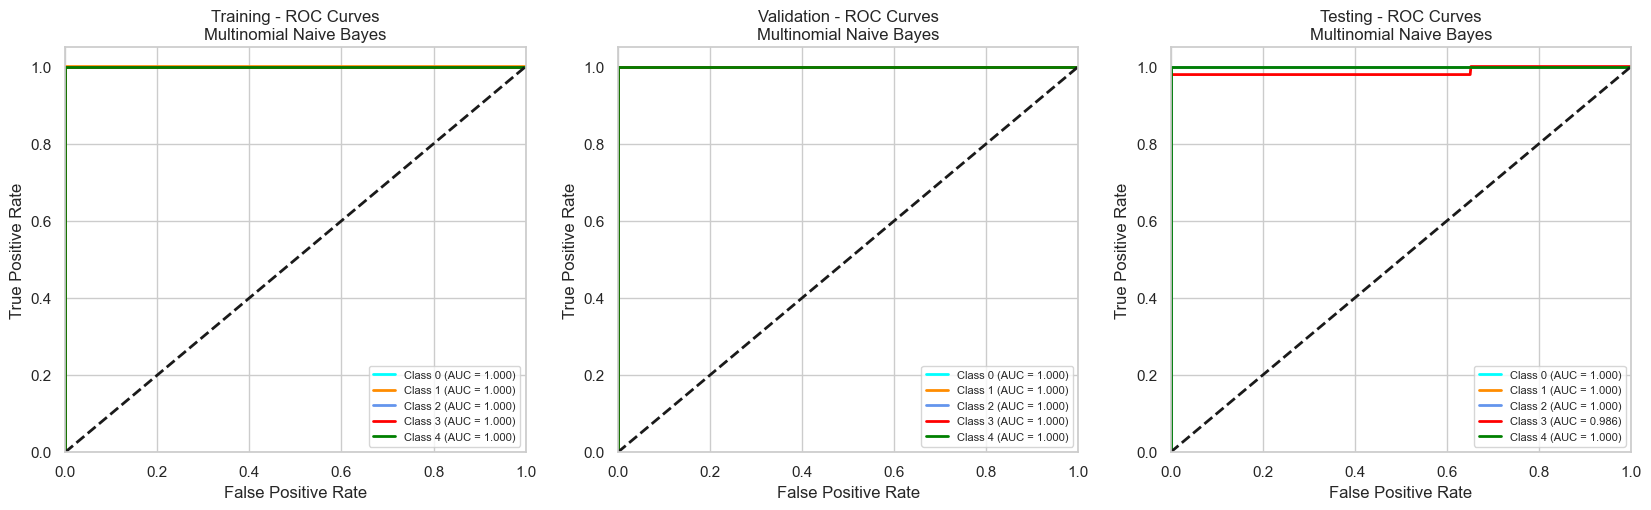

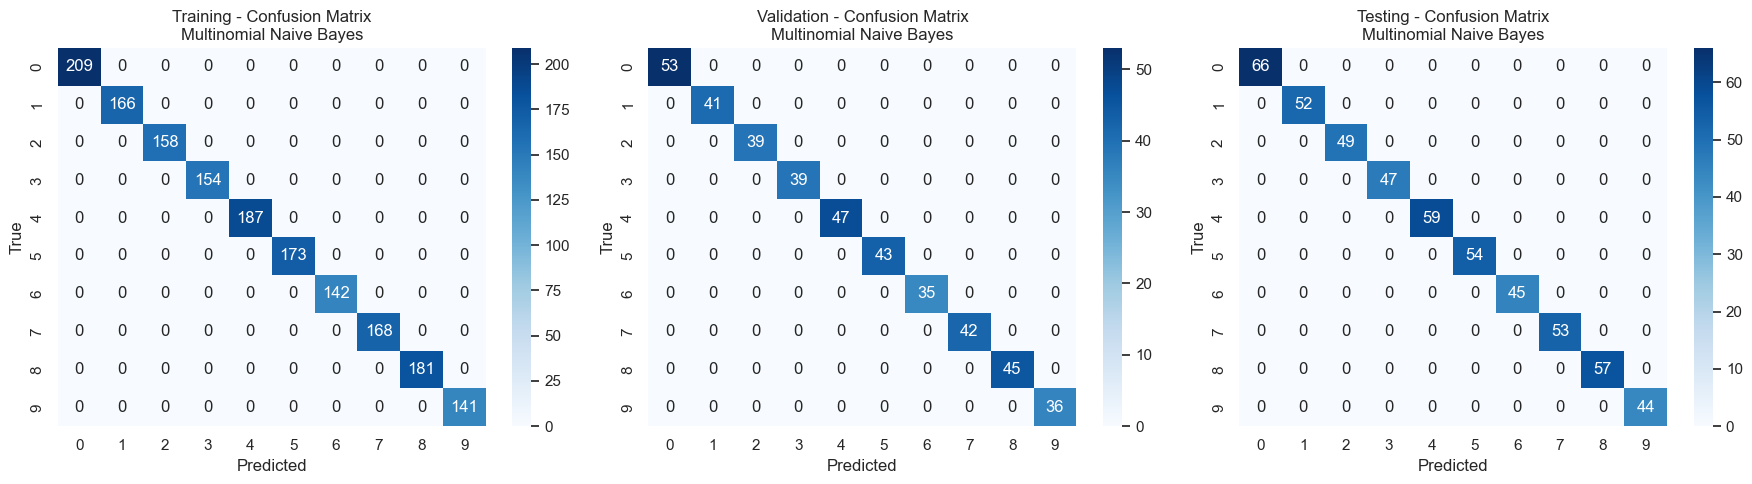

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Multinomial Naive Bayes
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9937     0.9939  0.9937    0.9937     4262
Validation    0.9944     0.9946  0.9944    0.9944     1066
   Testing    0.9917     0.9923  0.9917    0.9917     1333


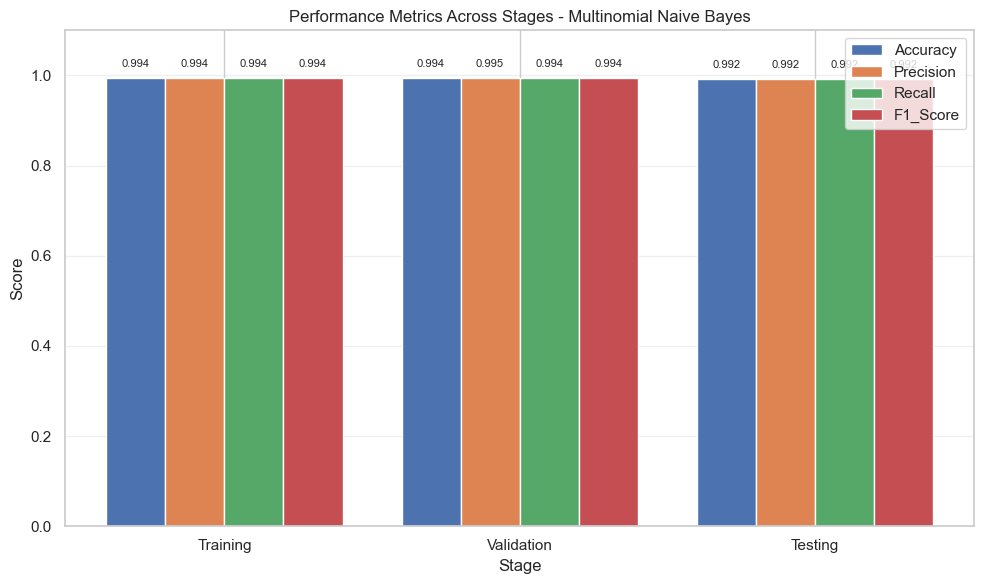


2. TRAINING LOGISTIC REGRESSION

COMPREHENSIVE EVALUATION FOR LOGISTIC REGRESSION

COMPREHENSIVE EVALUATION FOR LOGISTIC REGRESSION


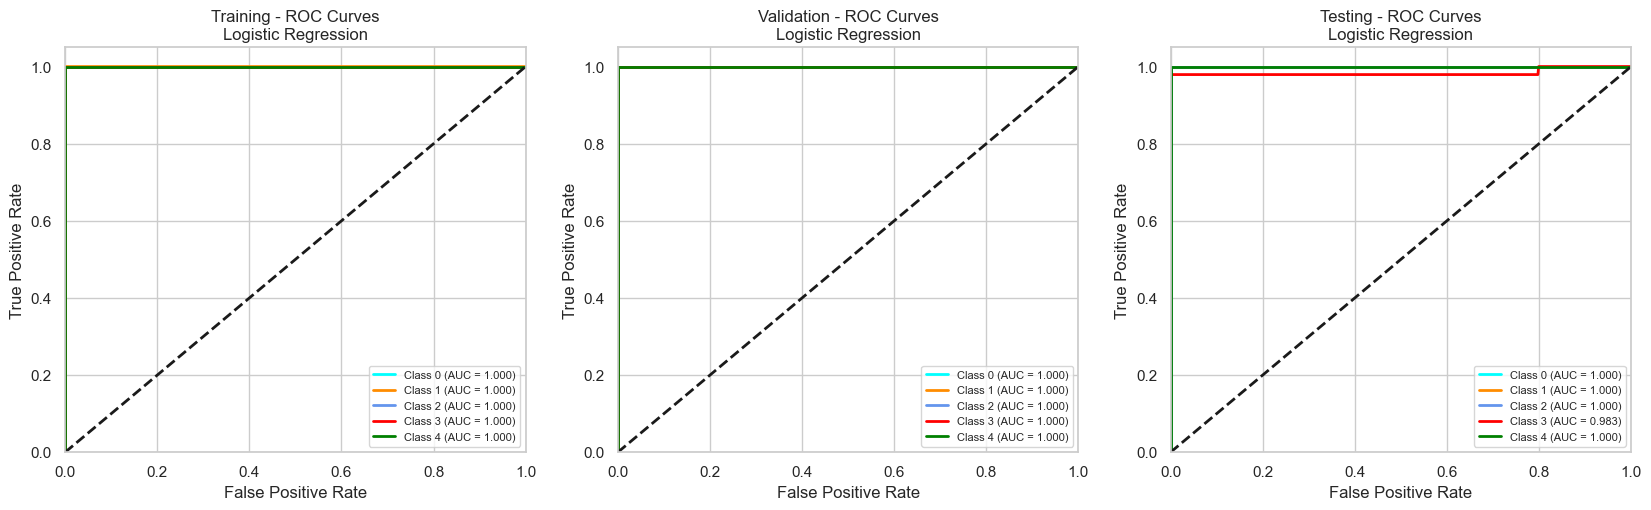

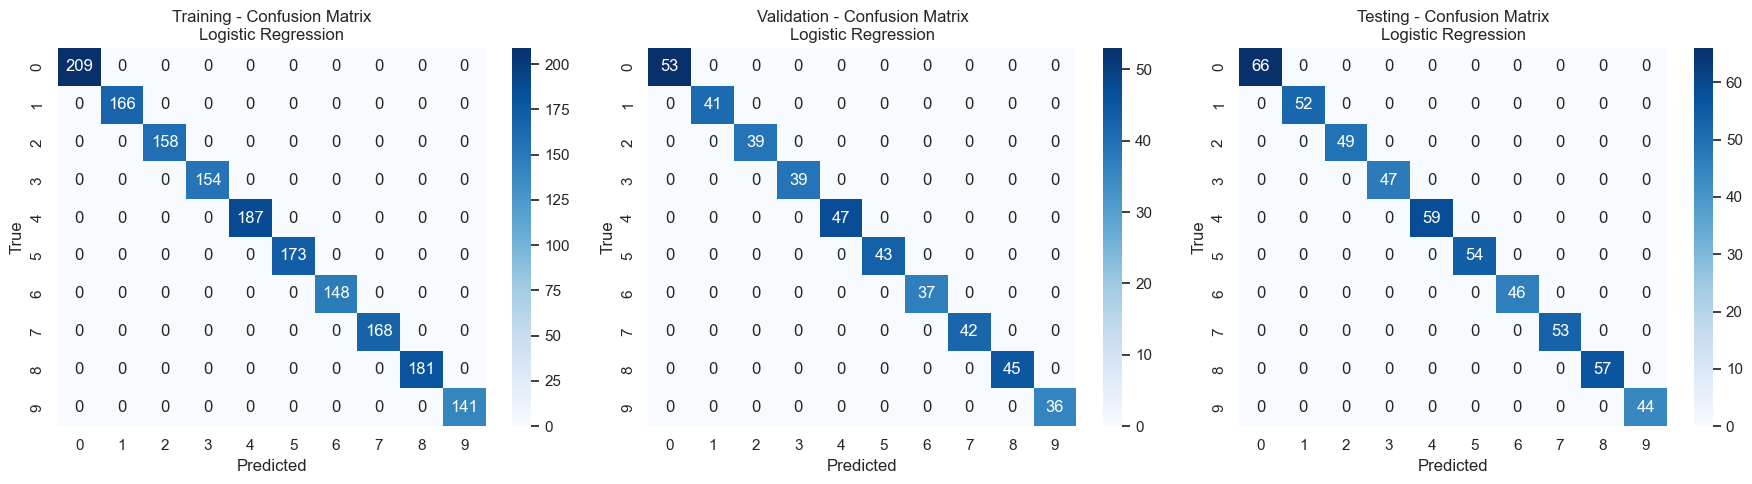

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Logistic Regression
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9958     0.9959  0.9958    0.9958     4262
Validation    0.9981     0.9982  0.9981    0.9981     1066
   Testing    0.9940     0.9945  0.9940    0.9940     1333


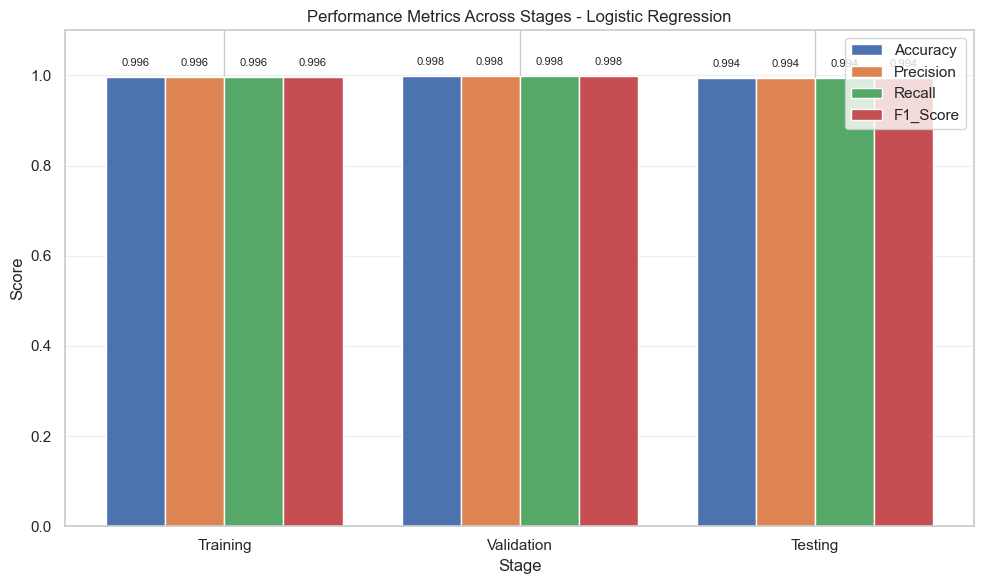


3. TRAINING SUPPORT VECTOR MACHINE

COMPREHENSIVE EVALUATION FOR SUPPORT VECTOR MACHINE

COMPREHENSIVE EVALUATION FOR SUPPORT VECTOR MACHINE


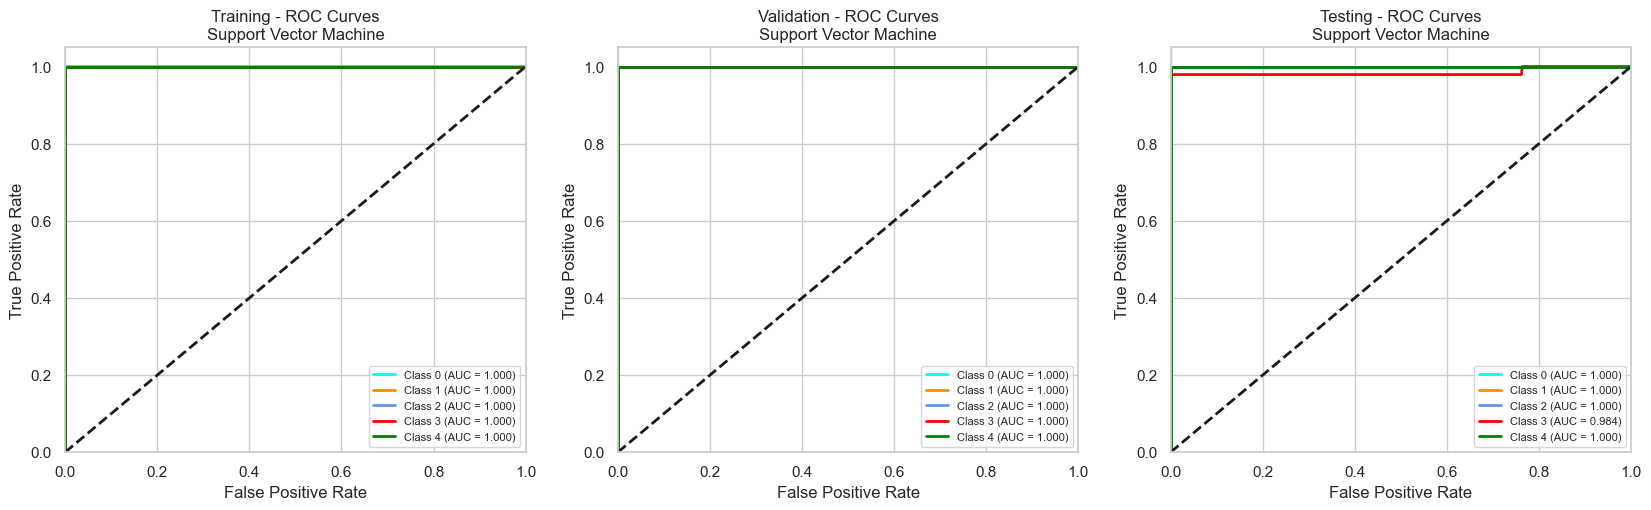

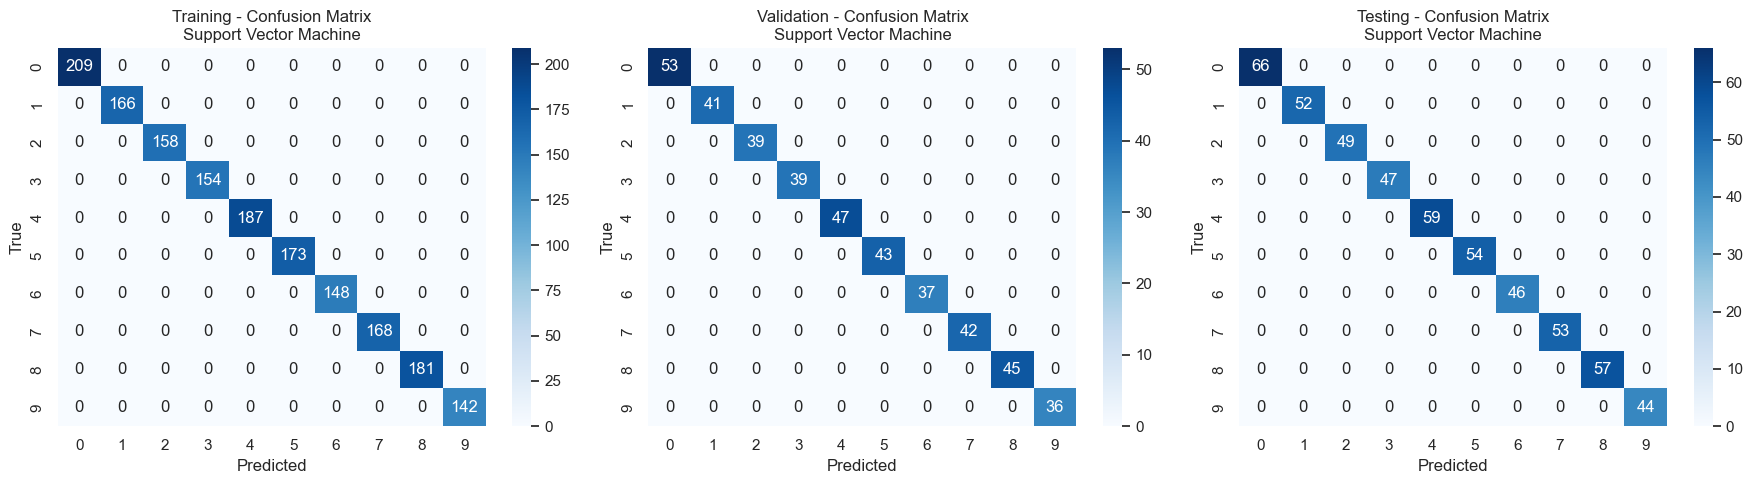

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Support Vector Machine
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9979     0.9979  0.9979    0.9979     4262
Validation    0.9991     0.9991  0.9991    0.9991     1066
   Testing    0.9955     0.9958  0.9955    0.9955     1333


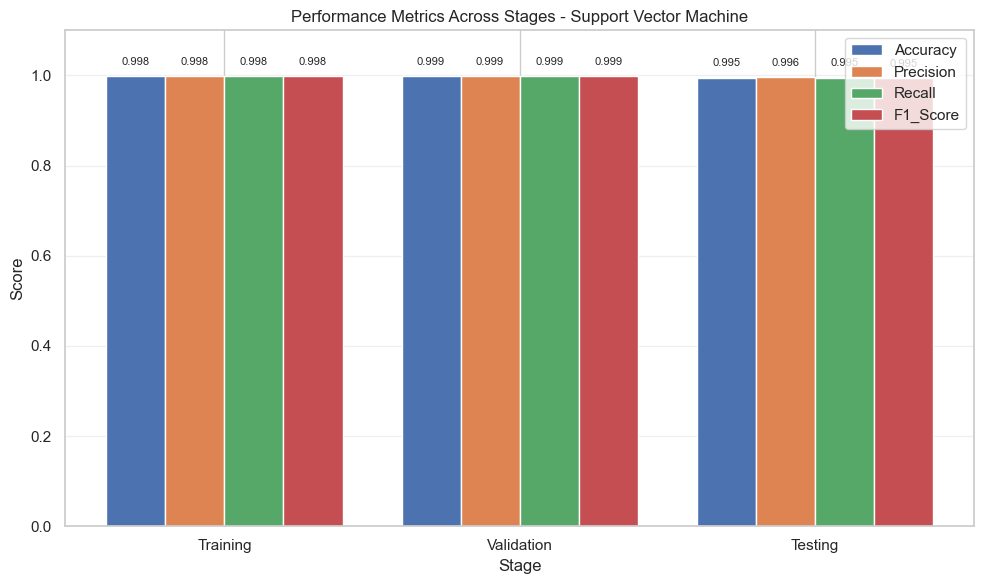


4. TRAINING RANDOM FOREST

COMPREHENSIVE EVALUATION FOR RANDOM FOREST

COMPREHENSIVE EVALUATION FOR RANDOM FOREST


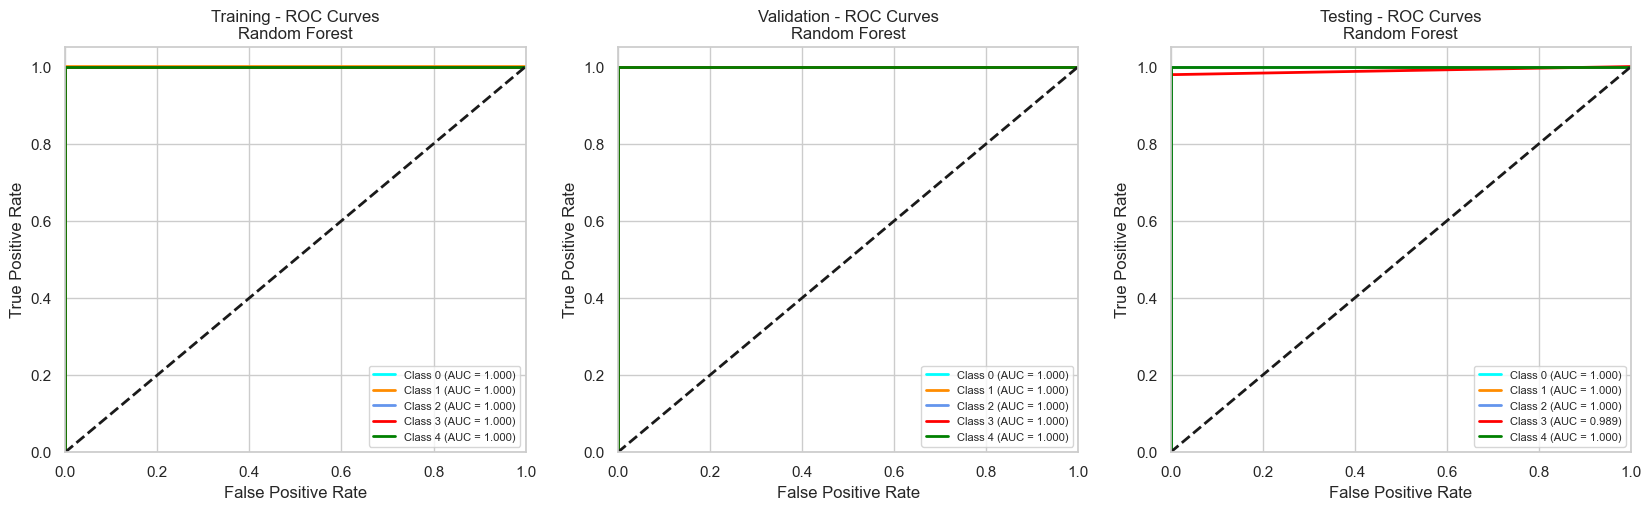

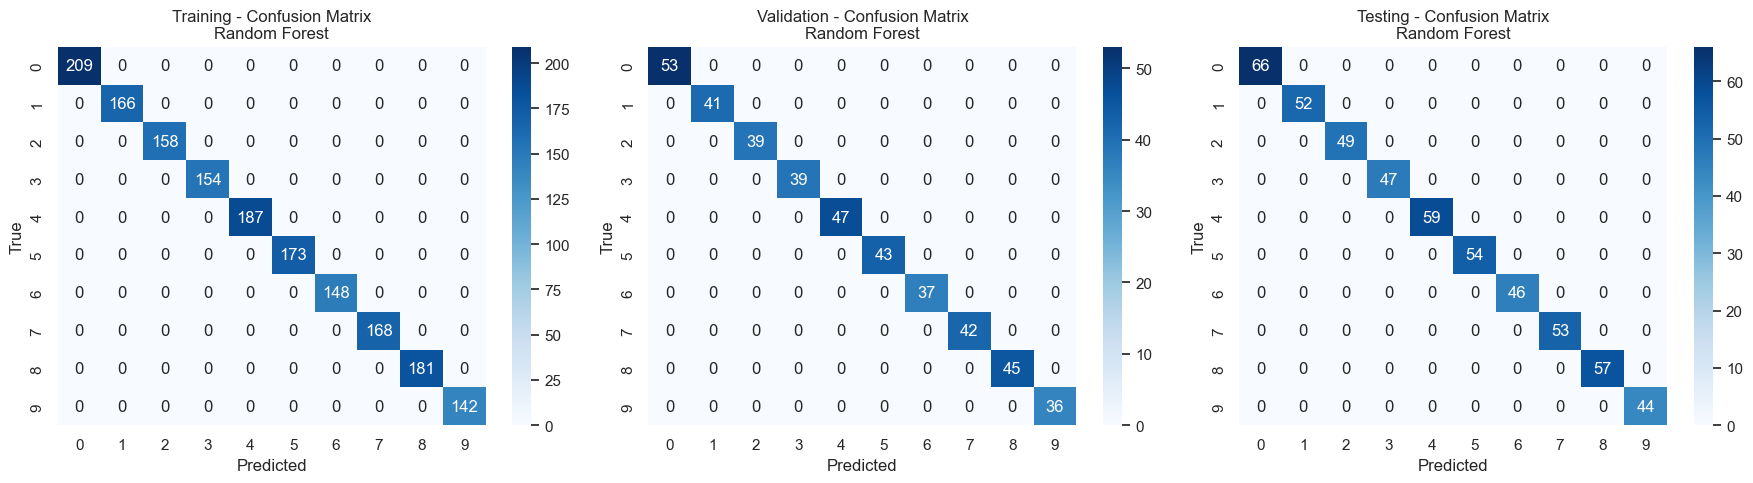

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Random Forest
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9979     0.9979  0.9979    0.9979     4262
Validation    0.9991     0.9991  0.9991    0.9991     1066
   Testing    0.9947     0.9951  0.9947    0.9947     1333


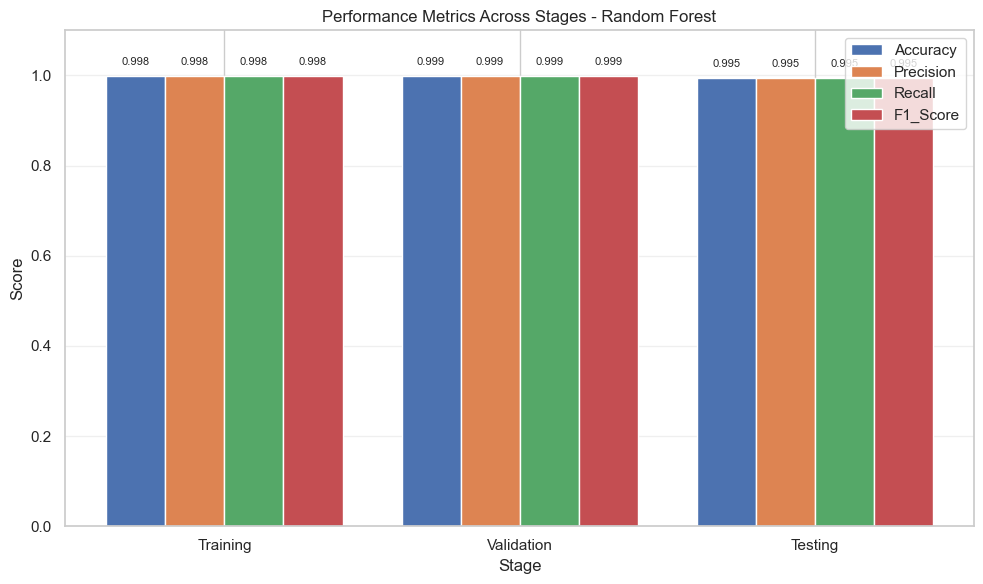


5. TRAINING SIMPLE NEURAL NETWORK
Epoch 1/10
67/67 [==============================] - 2s 20ms/step - loss: 3.1457 - accuracy: 0.2058 - val_loss: 2.9989 - val_accuracy: 0.6135
Epoch 2/10
67/67 [==============================] - 2s 20ms/step - loss: 3.1457 - accuracy: 0.2058 - val_loss: 2.9989 - val_accuracy: 0.6135
Epoch 2/10
67/67 [==============================] - 1s 20ms/step - loss: 2.5770 - accuracy: 0.5917 - val_loss: 1.8839 - val_accuracy: 0.7992
Epoch 3/10
67/67 [==============================] - 1s 20ms/step - loss: 2.5770 - accuracy: 0.5917 - val_loss: 1.8839 - val_accuracy: 0.7992
Epoch 3/10
67/67 [==============================] - 1s 18ms/step - loss: 1.2765 - accuracy: 0.8297 - val_loss: 0.6547 - val_accuracy: 0.9165
Epoch 4/10
67/67 [==============================] - 1s 18ms/step - loss: 1.2765 - accuracy: 0.8297 - val_loss: 0.6547 - val_accuracy: 0.9165
Epoch 4/10
67/67 [==============================] - 1s 17ms/step - loss: 0.5133 - accuracy: 0.9230 - val_loss: 0.2540 -

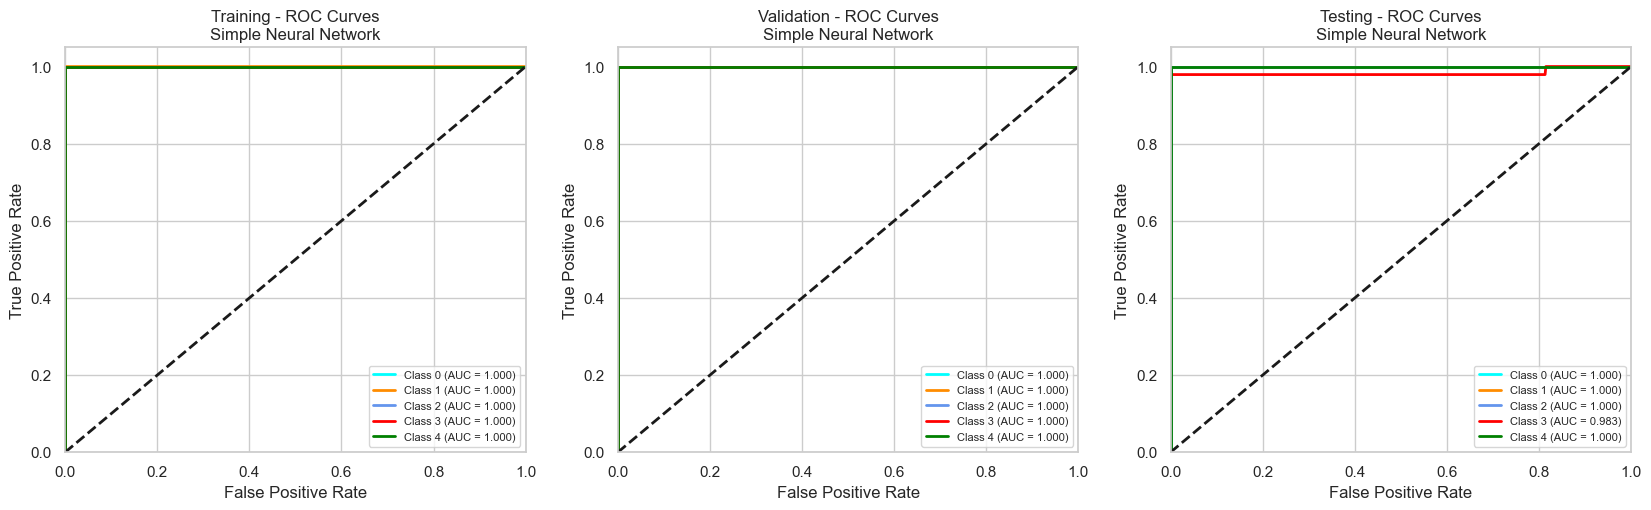

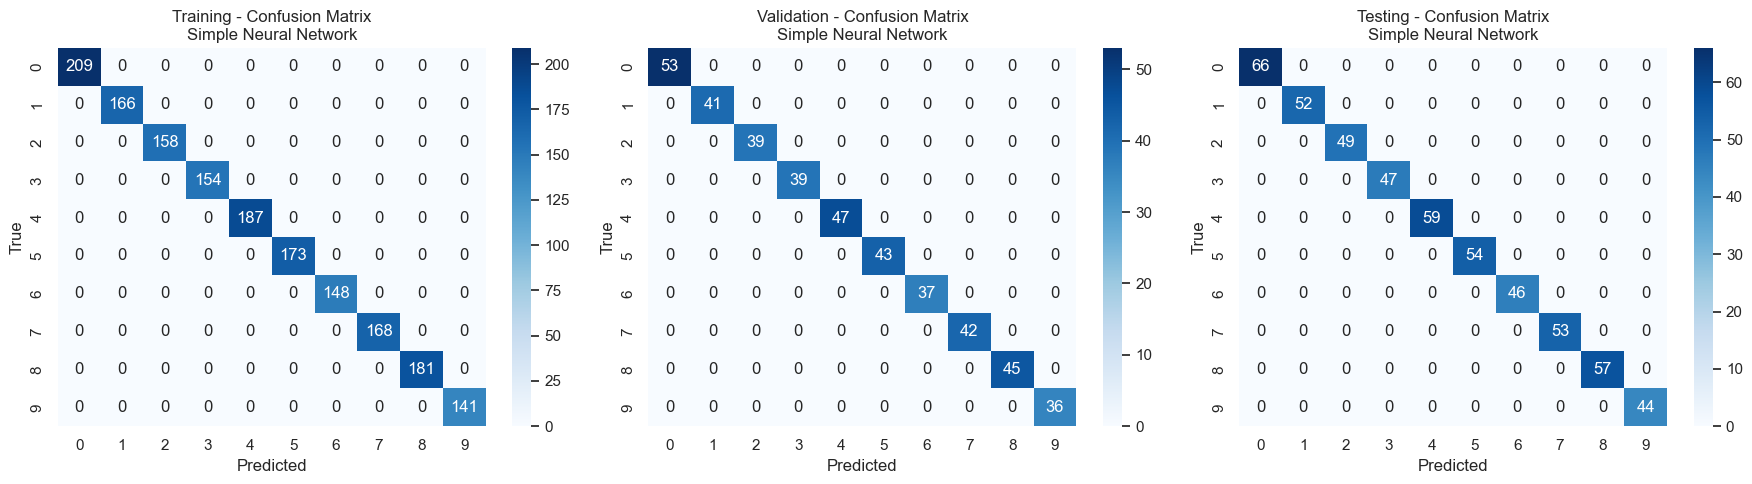

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Simple Neural Network
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9958     0.9959  0.9958    0.9958     4262
Validation    0.9981     0.9982  0.9981    0.9981     1066
   Testing    0.9947     0.9952  0.9947    0.9947     1333


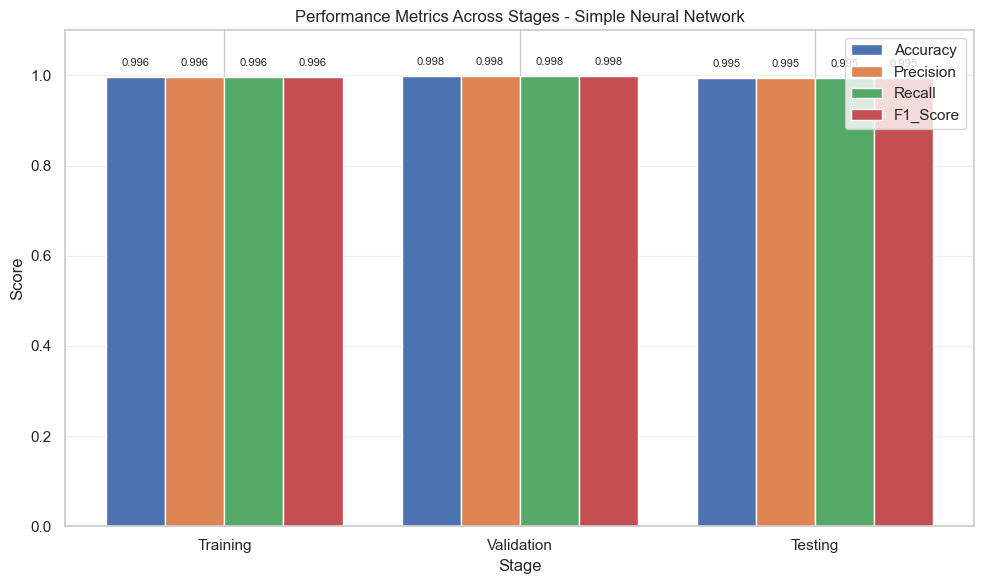


6. TRAINING CNN FOR TEXT CLASSIFICATION
Epoch 1/10
67/67 [==============================] - 5s 53ms/step - loss: 3.1868 - accuracy: 0.0631 - val_loss: 3.0727 - val_accuracy: 0.0891
Epoch 2/10
67/67 [==============================] - 5s 53ms/step - loss: 3.1868 - accuracy: 0.0631 - val_loss: 3.0727 - val_accuracy: 0.0891
Epoch 2/10
67/67 [==============================] - 4s 53ms/step - loss: 2.4356 - accuracy: 0.2921 - val_loss: 1.3313 - val_accuracy: 0.6829
Epoch 3/10
67/67 [==============================] - 4s 53ms/step - loss: 2.4356 - accuracy: 0.2921 - val_loss: 1.3313 - val_accuracy: 0.6829
Epoch 3/10
67/67 [==============================] - 3s 51ms/step - loss: 1.0104 - accuracy: 0.6891 - val_loss: 0.3127 - val_accuracy: 0.9784
Epoch 4/10
67/67 [==============================] - 3s 51ms/step - loss: 1.0104 - accuracy: 0.6891 - val_loss: 0.3127 - val_accuracy: 0.9784
Epoch 4/10
67/67 [==============================] - 3s 51ms/step - loss: 0.4337 - accuracy: 0.8794 - val_loss: 0.

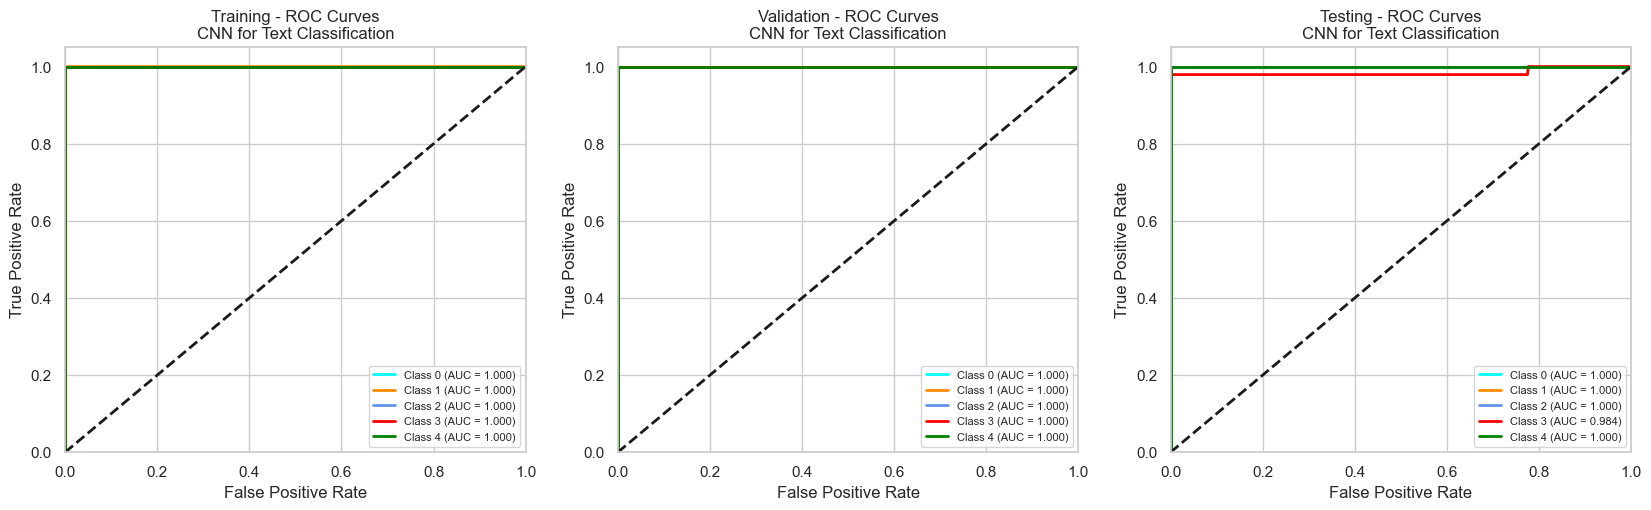

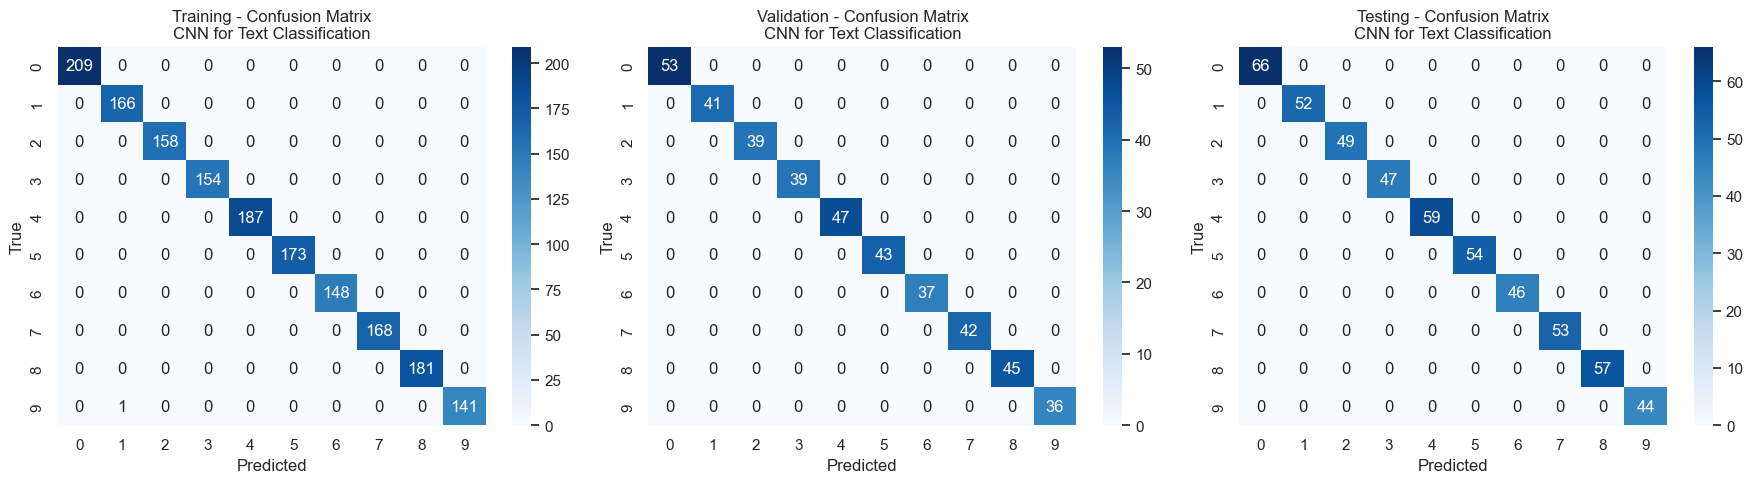

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - CNN for Text Classification
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9969     0.9970  0.9969    0.9970     4262
Validation    0.9972     0.9973  0.9972    0.9972     1066
   Testing    0.9970     0.9971  0.9970    0.9970     1333


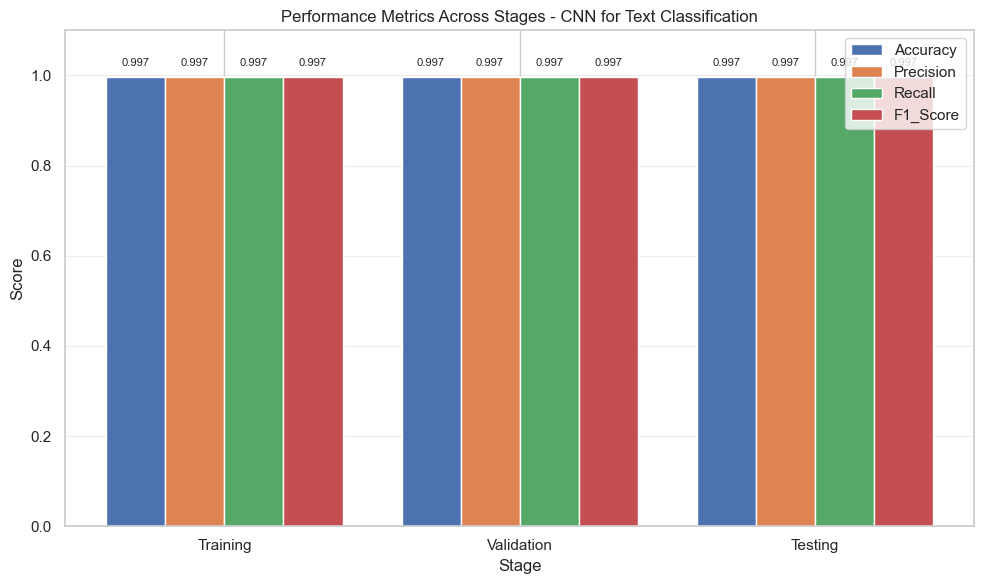


7. TRAINING LSTM NETWORK
Epoch 1/10
Epoch 1/10
67/67 [==============================] - 36s 492ms/step - loss: 3.2202 - accuracy: 0.0366 - val_loss: 3.2158 - val_accuracy: 0.0460
Epoch 2/10
67/67 [==============================] - 36s 492ms/step - loss: 3.2202 - accuracy: 0.0366 - val_loss: 3.2158 - val_accuracy: 0.0460
Epoch 2/10
67/67 [==============================] - 32s 473ms/step - loss: 3.2163 - accuracy: 0.0495 - val_loss: 3.2139 - val_accuracy: 0.0497
Epoch 3/10
67/67 [==============================] - 32s 473ms/step - loss: 3.2163 - accuracy: 0.0495 - val_loss: 3.2139 - val_accuracy: 0.0497
Epoch 3/10
67/67 [==============================] - 32s 471ms/step - loss: 3.2161 - accuracy: 0.0472 - val_loss: 3.2132 - val_accuracy: 0.0497
Epoch 4/10
67/67 [==============================] - 32s 471ms/step - loss: 3.2161 - accuracy: 0.0472 - val_loss: 3.2132 - val_accuracy: 0.0497
Epoch 4/10
67/67 [==============================] - 32s 475ms/step - loss: 3.2157 - accuracy: 0.0476 - va

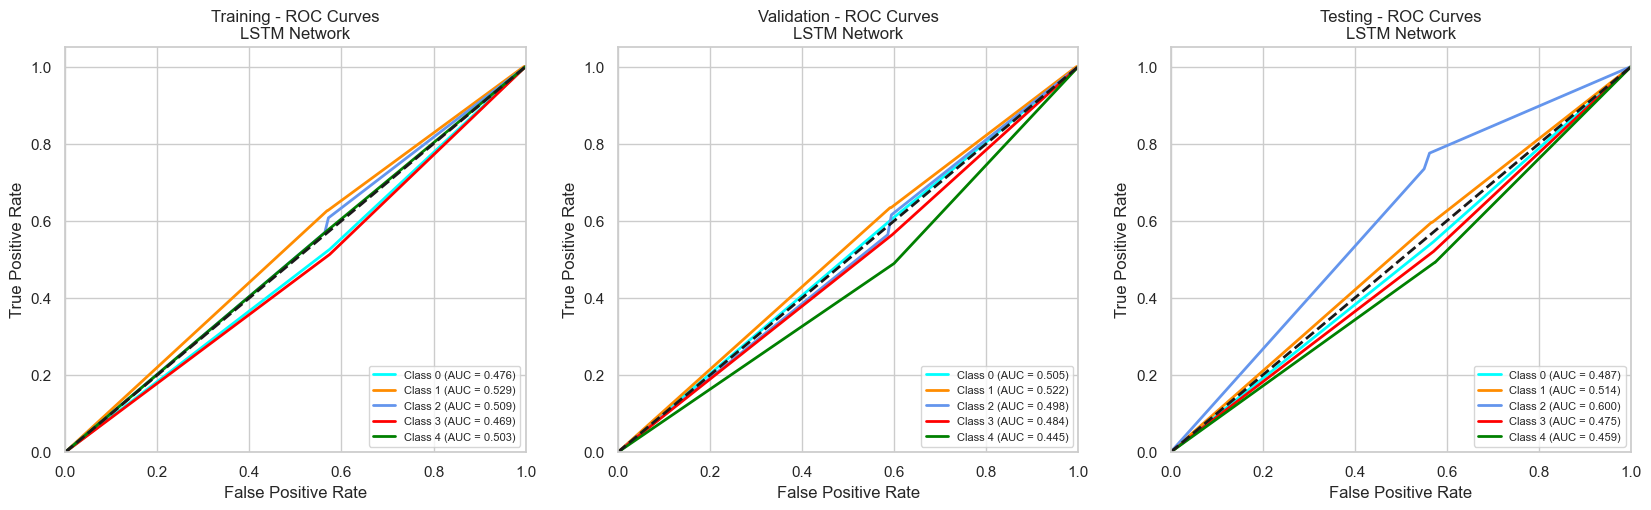

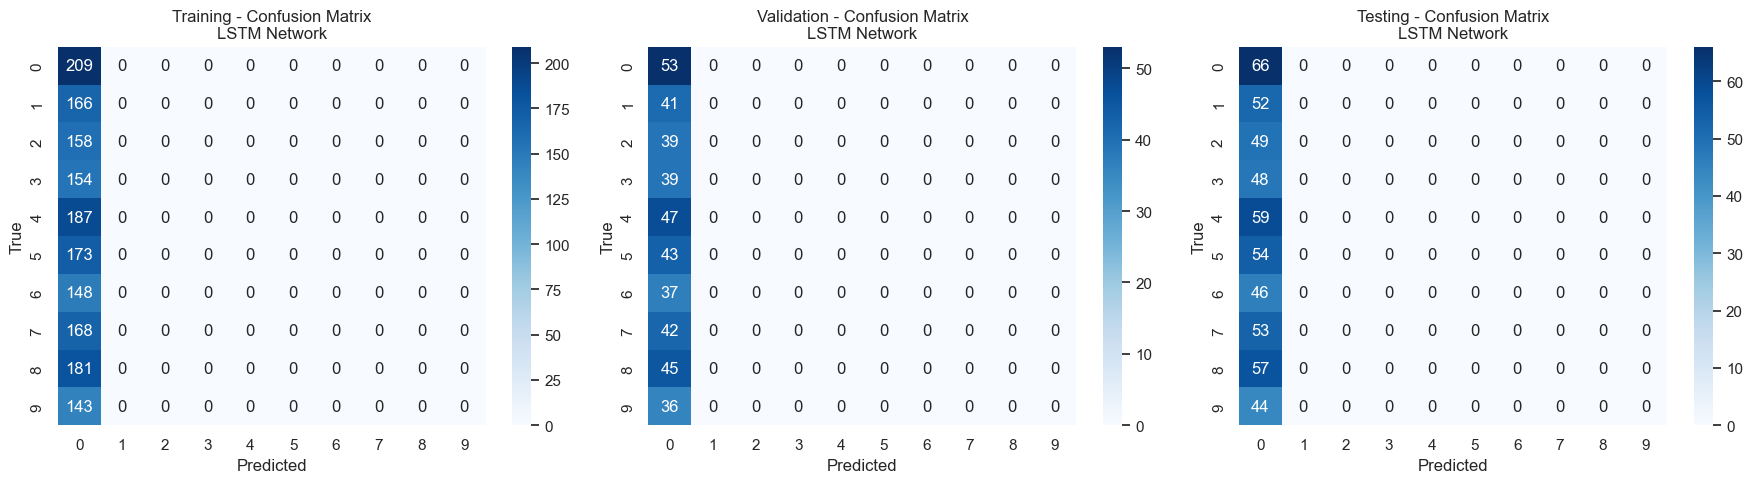

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - LSTM Network
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.0490     0.0024  0.0490    0.0046     4262
Validation    0.0497     0.0025  0.0497    0.0047     1066
   Testing    0.0495     0.0025  0.0495    0.0047     1333


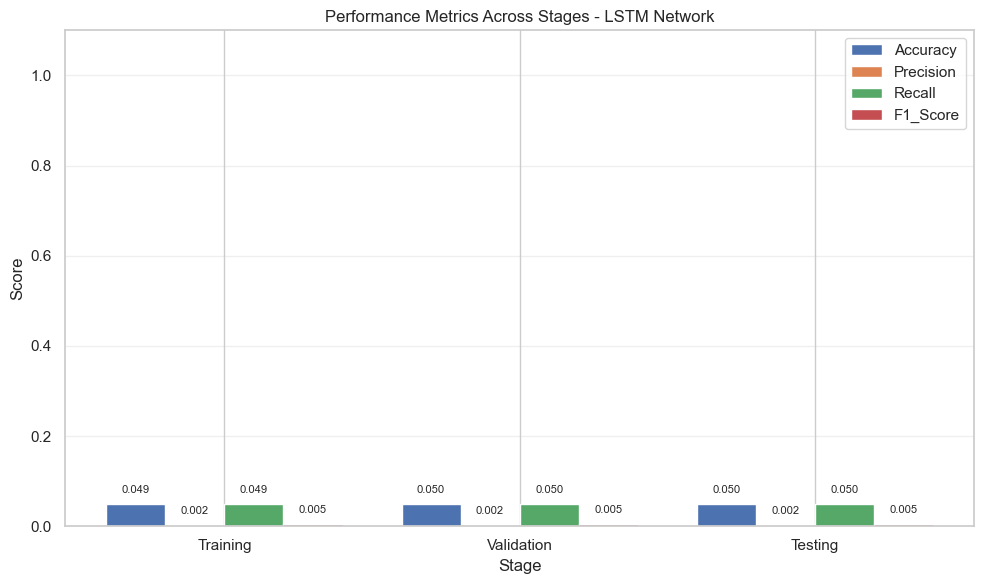


8. TRAINING BIDIRECTIONAL LSTM
Epoch 1/10
Epoch 1/10
67/67 [==============================] - 69s 879ms/step - loss: 3.1777 - accuracy: 0.0706 - val_loss: 2.9277 - val_accuracy: 0.1745
Epoch 2/10
67/67 [==============================] - 69s 879ms/step - loss: 3.1777 - accuracy: 0.0706 - val_loss: 2.9277 - val_accuracy: 0.1745
Epoch 2/10
67/67 [==============================] - 58s 873ms/step - loss: 2.3920 - accuracy: 0.2440 - val_loss: 1.5115 - val_accuracy: 0.5694
Epoch 3/10
67/67 [==============================] - 58s 873ms/step - loss: 2.3920 - accuracy: 0.2440 - val_loss: 1.5115 - val_accuracy: 0.5694
Epoch 3/10
67/67 [==============================] - 62s 919ms/step - loss: 1.4277 - accuracy: 0.5232 - val_loss: 0.7406 - val_accuracy: 0.8302
Epoch 4/10
67/67 [==============================] - 62s 919ms/step - loss: 1.4277 - accuracy: 0.5232 - val_loss: 0.7406 - val_accuracy: 0.8302
Epoch 4/10
67/67 [==============================] - 59s 882ms/step - loss: 0.8514 - accuracy: 0.740

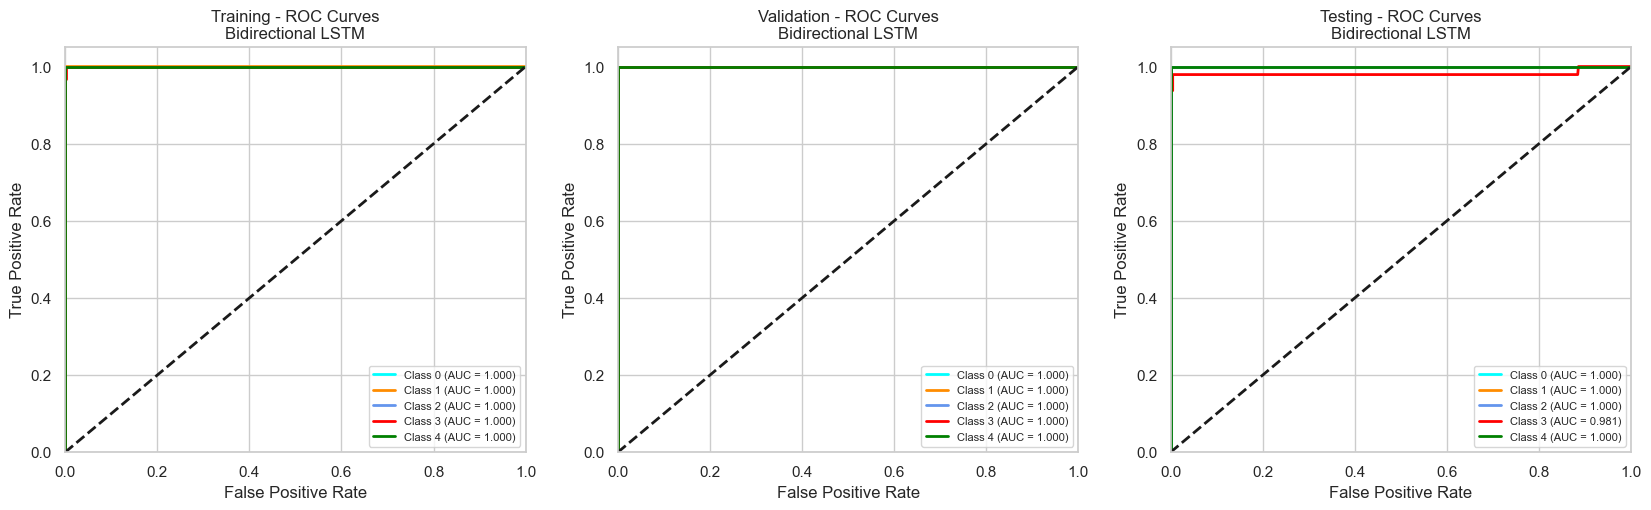

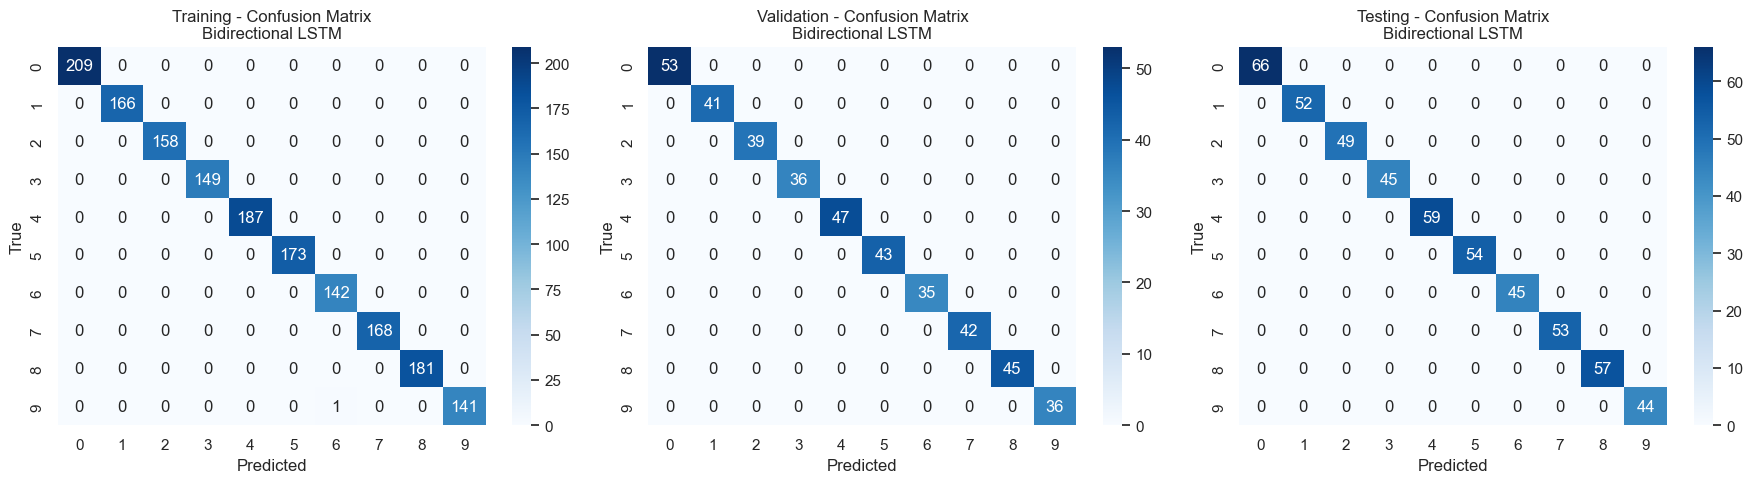

<Figure size 640x480 with 0 Axes>


PERFORMANCE METRICS TABLE - Bidirectional LSTM
     Stage  Accuracy  Precision  Recall  F1_Score  Support
  Training    0.9913     0.9916  0.9913    0.9913     4262
Validation    0.9906     0.9910  0.9906    0.9906     1066
   Testing    0.9872     0.9879  0.9872    0.9872     1333


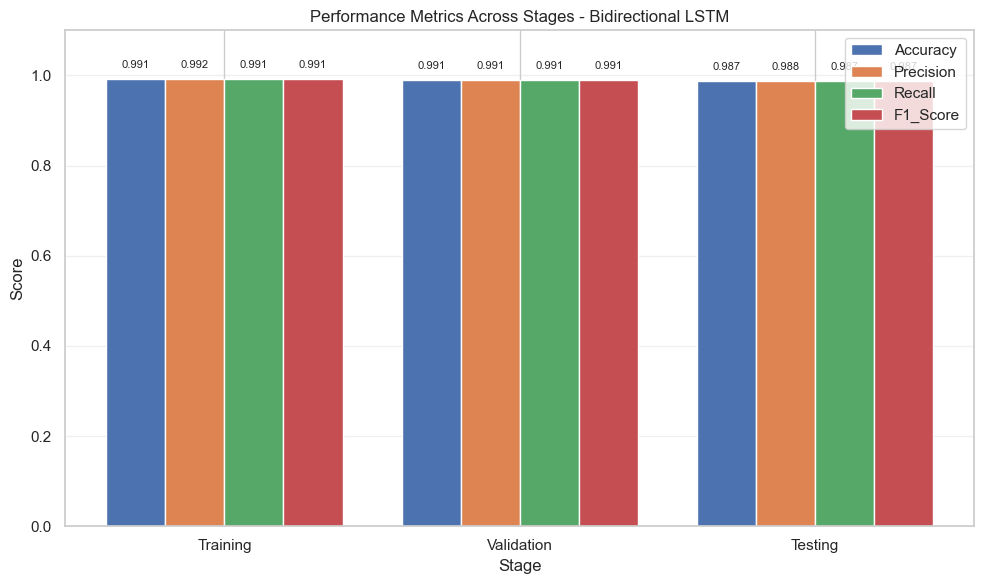


COMPREHENSIVE EVALUATION COMPLETED


In [76]:
# Initialize storage for all model results
all_model_results = {}

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting comprehensive model evaluation...")
print("Each model will be evaluated on Training, Validation, and Testing stages")
print("Generating confusion matrices, ROC curves, and performance tables for each stage")

# 1. MULTINOMIAL NAIVE BAYES
print(f"\n{'='*60}")
print("1. TRAINING MULTINOMIAL NAIVE BAYES")
print(f"{'='*60}")

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

all_model_results['Multinomial Naive Bayes'] = comprehensive_evaluation(
    nb_model, X_train_tfidf, X_val_tfidf, X_test_tfidf, 
    y_train, y_val, y_test, 'Multinomial Naive Bayes'
)

# 2. LOGISTIC REGRESSION
print(f"\n{'='*60}")
print("2. TRAINING LOGISTIC REGRESSION")
print(f"{'='*60}")

lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='liblinear')
lr_model.fit(X_train_tfidf, y_train)

all_model_results['Logistic Regression'] = comprehensive_evaluation(
    lr_model, X_train_tfidf, X_val_tfidf, X_test_tfidf,
    y_train, y_val, y_test, 'Logistic Regression'
)

# 3. SUPPORT VECTOR MACHINE
print(f"\n{'='*60}")
print("3. TRAINING SUPPORT VECTOR MACHINE")
print(f"{'='*60}")

svm_model = LinearSVC(C=1.0, max_iter=10000)
svm_model.fit(X_train_tfidf, y_train)

# Note: LinearSVC doesn't have predict_proba, so we'll use decision_function
class SVMWithProba:
    def __init__(self, model):
        self.model = model
    
    def predict(self, X):
        return self.model.predict(X)
    
    def predict_proba(self, X):
        # Convert decision function to probabilities using softmax
        decision = self.model.decision_function(X)
        if decision.ndim == 1:
            decision = decision.reshape(-1, 1)
            decision = np.hstack([-decision, decision])
        exp_decision = np.exp(decision - np.max(decision, axis=1, keepdims=True))
        return exp_decision / np.sum(exp_decision, axis=1, keepdims=True)

svm_with_proba = SVMWithProba(svm_model)

all_model_results['Support Vector Machine'] = comprehensive_evaluation(
    svm_with_proba, X_train_tfidf, X_val_tfidf, X_test_tfidf,
    y_train, y_val, y_test, 'Support Vector Machine'
)

# 4. RANDOM FOREST
print(f"\n{'='*60}")
print("4. TRAINING RANDOM FOREST")
print(f"{'='*60}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

all_model_results['Random Forest'] = comprehensive_evaluation(
    rf_model, X_train_tfidf, X_val_tfidf, X_test_tfidf,
    y_train, y_val, y_test, 'Random Forest'
)

# 5. SIMPLE NEURAL NETWORK
print(f"\n{'='*60}")
print("5. TRAINING SIMPLE NEURAL NETWORK")
print(f"{'='*60}")

nn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

nn_history = nn_model.fit(
    X_train_pad, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

all_model_results['Simple Neural Network'] = comprehensive_evaluation(
    nn_model, X_train_pad, X_val_pad, X_test_pad,
    y_train, y_val, y_test, 'Simple Neural Network', is_neural_network=True
)

# 6. CNN FOR TEXT CLASSIFICATION
print(f"\n{'='*60}")
print("6. TRAINING CNN FOR TEXT CLASSIFICATION")
print(f"{'='*60}")

cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_history = cnn_model.fit(
    X_train_pad, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

all_model_results['CNN for Text Classification'] = comprehensive_evaluation(
    cnn_model, X_train_pad, X_val_pad, X_test_pad,
    y_train, y_val, y_test, 'CNN for Text Classification', is_neural_network=True
)

# 7. LSTM NETWORK
print(f"\n{'='*60}")
print("7. TRAINING LSTM NETWORK")
print(f"{'='*60}")

lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

lstm_history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

all_model_results['LSTM Network'] = comprehensive_evaluation(
    lstm_model, X_train_pad, X_val_pad, X_test_pad,
    y_train, y_val, y_test, 'LSTM Network', is_neural_network=True
)

# 8. BIDIRECTIONAL LSTM
print(f"\n{'='*60}")
print("8. TRAINING BIDIRECTIONAL LSTM")
print(f"{'='*60}")

bi_lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

bi_lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

bi_lstm_history = bi_lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_val_pad, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

all_model_results['Bidirectional LSTM'] = comprehensive_evaluation(
    bi_lstm_model, X_train_pad, X_val_pad, X_test_pad,
    y_train, y_val, y_test, 'Bidirectional LSTM', is_neural_network=True
)

print(f"\n{'='*60}")
print("COMPREHENSIVE EVALUATION COMPLETED")
print(f"{'='*60}")

## 6. Model Comparison and Final Analysis

Now we'll create a comprehensive comparison of all models across all three stages (training, validation, testing) and determine the best performing model.

COMPREHENSIVE MODEL COMPARISON ACROSS ALL STAGES

ACCURACY COMPARISON:
--------------------------------------------------
Stage                        Training  Validation  Testing
Model                                                     
Bidirectional LSTM             0.9913      0.9906   0.9872
CNN for Text Classification    0.9969      0.9972   0.9970
LSTM Network                   0.0490      0.0497   0.0495
Logistic Regression            0.9958      0.9981   0.9940
Multinomial Naive Bayes        0.9937      0.9944   0.9917
Random Forest                  0.9979      0.9991   0.9947
Simple Neural Network          0.9958      0.9981   0.9947
Support Vector Machine         0.9979      0.9991   0.9955


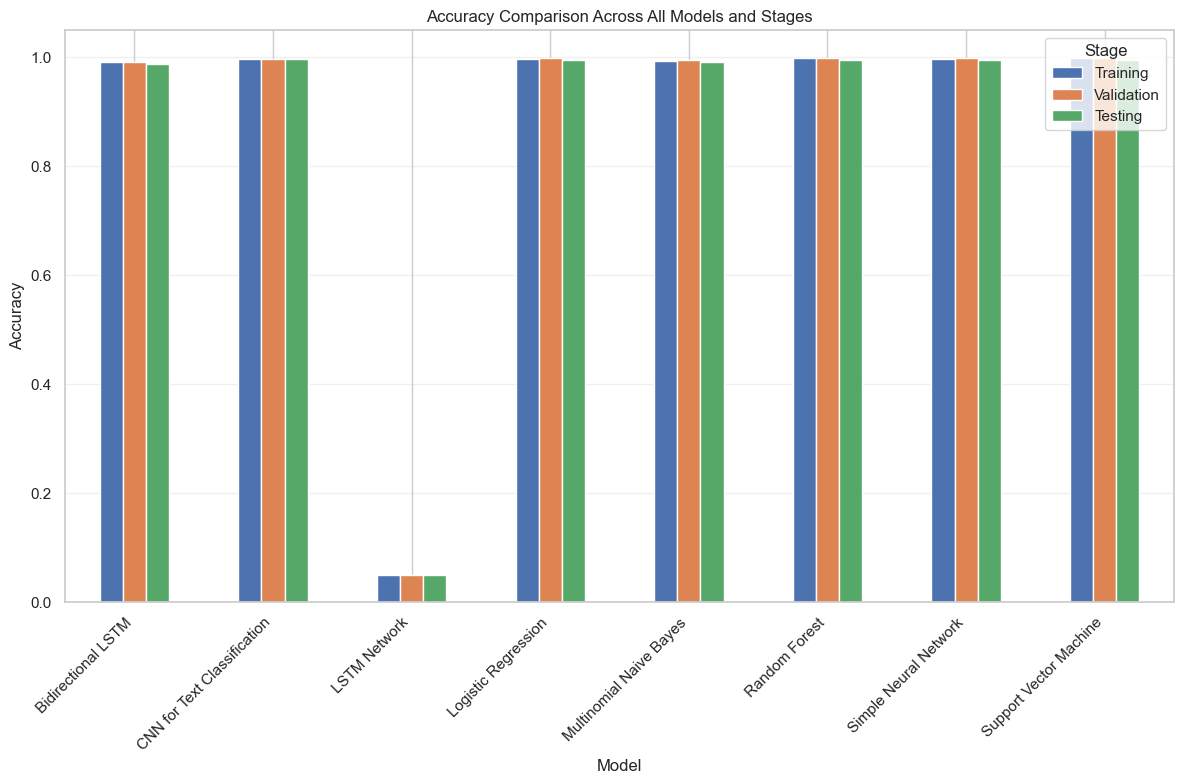


PRECISION COMPARISON:
--------------------------------------------------
Stage                        Training  Validation  Testing
Model                                                     
Bidirectional LSTM             0.9916      0.9910   0.9879
CNN for Text Classification    0.9970      0.9973   0.9971
LSTM Network                   0.0024      0.0025   0.0025
Logistic Regression            0.9959      0.9982   0.9945
Multinomial Naive Bayes        0.9939      0.9946   0.9923
Random Forest                  0.9979      0.9991   0.9951
Simple Neural Network          0.9959      0.9982   0.9952
Support Vector Machine         0.9979      0.9991   0.9958


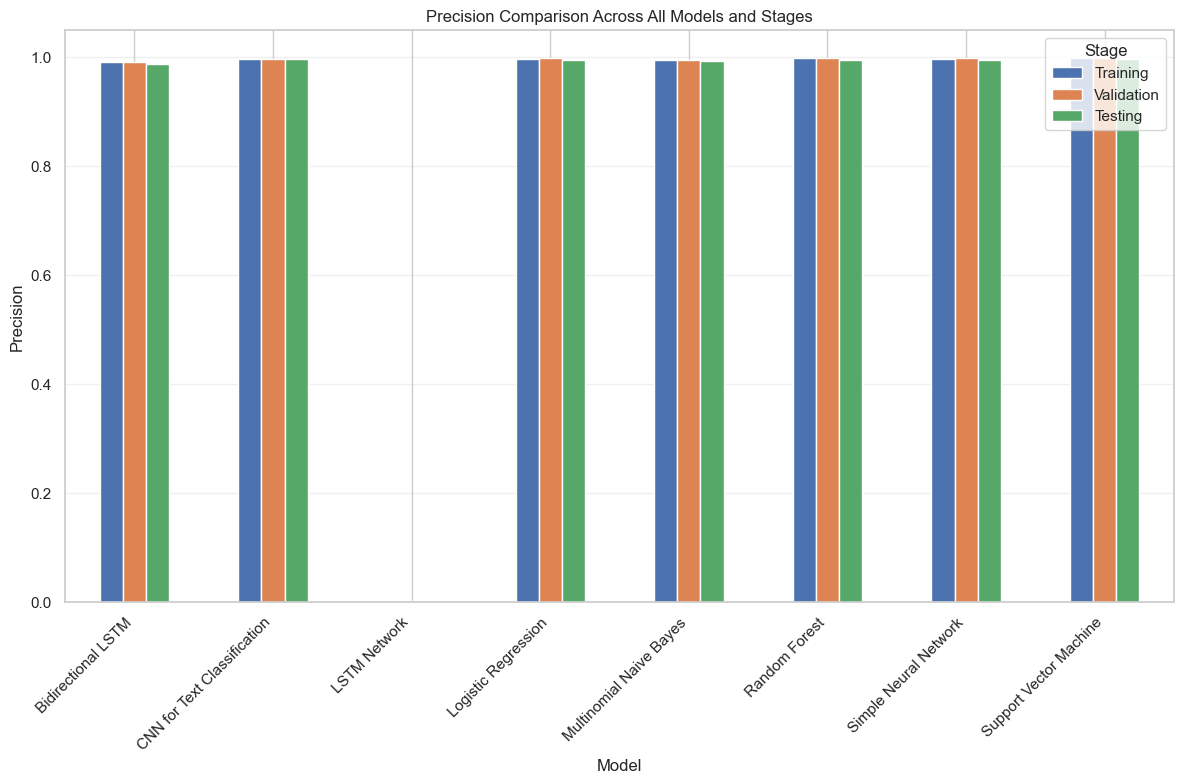


RECALL COMPARISON:
--------------------------------------------------
Stage                        Training  Validation  Testing
Model                                                     
Bidirectional LSTM             0.9913      0.9906   0.9872
CNN for Text Classification    0.9969      0.9972   0.9970
LSTM Network                   0.0490      0.0497   0.0495
Logistic Regression            0.9958      0.9981   0.9940
Multinomial Naive Bayes        0.9937      0.9944   0.9917
Random Forest                  0.9979      0.9991   0.9947
Simple Neural Network          0.9958      0.9981   0.9947
Support Vector Machine         0.9979      0.9991   0.9955


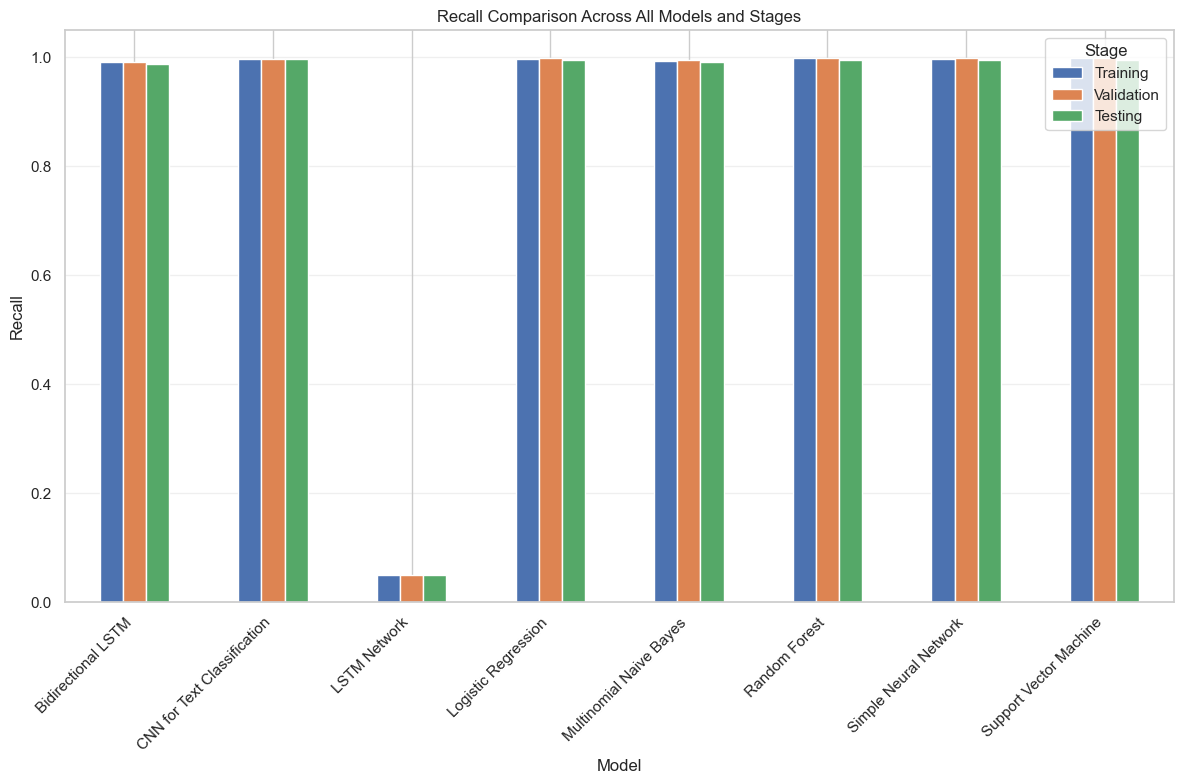


F1_SCORE COMPARISON:
--------------------------------------------------
Stage                        Training  Validation  Testing
Model                                                     
Bidirectional LSTM             0.9913      0.9906   0.9872
CNN for Text Classification    0.9970      0.9972   0.9970
LSTM Network                   0.0046      0.0047   0.0047
Logistic Regression            0.9958      0.9981   0.9940
Multinomial Naive Bayes        0.9937      0.9944   0.9917
Random Forest                  0.9979      0.9991   0.9947
Simple Neural Network          0.9958      0.9981   0.9947
Support Vector Machine         0.9979      0.9991   0.9955


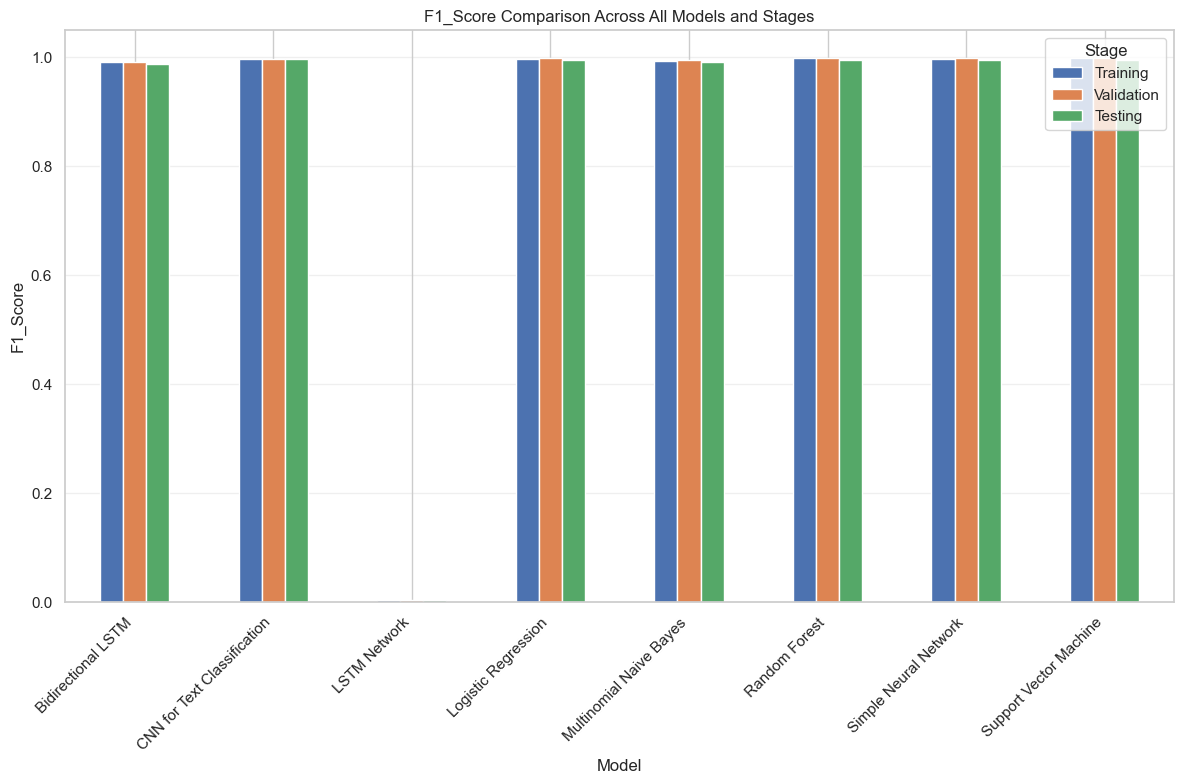


BEST PERFORMING MODELS BY STAGE:

Ranking by Testing F1-Score (most important metric):
1. CNN for Text Classification: F1=0.9970, Accuracy=0.9970
2. Support Vector Machine: F1=0.9955, Accuracy=0.9955
3. Random Forest: F1=0.9947, Accuracy=0.9947
4. Simple Neural Network: F1=0.9947, Accuracy=0.9947
5. Logistic Regression: F1=0.9940, Accuracy=0.9940
6. Multinomial Naive Bayes: F1=0.9917, Accuracy=0.9917
7. Bidirectional LSTM: F1=0.9872, Accuracy=0.9872
8. LSTM Network: F1=0.0047, Accuracy=0.0495

OVERFITTING ANALYSIS:
                         Model  Training_Accuracy  Testing_Accuracy  \
7           Bidirectional LSTM             0.9913            0.9872   
3                Random Forest             0.9979            0.9947   
2       Support Vector Machine             0.9979            0.9955   
0      Multinomial Naive Bayes             0.9937            0.9917   
1          Logistic Regression             0.9958            0.9940   
4        Simple Neural Network             0.9958   

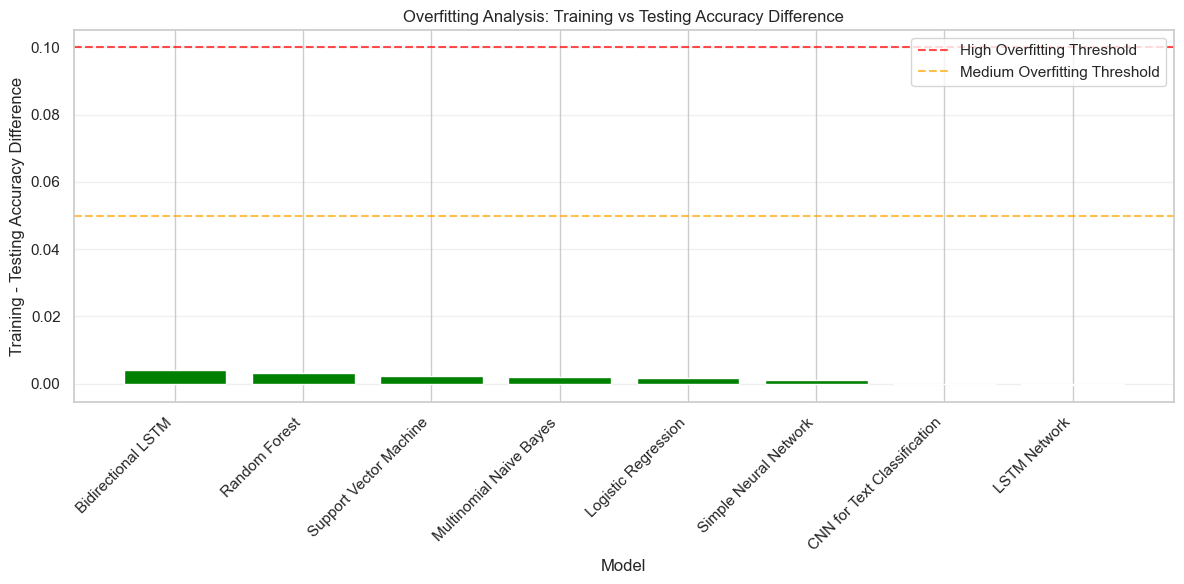


RECOMENDED MODEL: CNN for Text Classification
Testing Performance - Accuracy: 0.9970, F1-Score: 0.9970
Overfitting Risk: Low

RESEARCH HYPOTHESIS CONCLUSION:
H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support.
Based on CNN for Text Classification achieving F1-Score: 0.9970 and Accuracy: 0.9970
Threshold: 0.7


In [77]:
# Create comprehensive comparison table
comparison_data = []

for model_name, results in all_model_results.items():
    for stage in ['training', 'validation', 'testing']:
        stage_results = results[stage]
        comparison_data.append({
            'Model': model_name,
            'Stage': stage.capitalize(),
            'Accuracy': stage_results['accuracy'],
            'Precision': stage_results['precision'],
            'Recall': stage_results['recall'],
            'F1_Score': stage_results['f1_score']
        })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(comparison_data)

# Pivot table for better visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
stages = ['Training', 'Validation', 'Testing']

print("COMPREHENSIVE MODEL COMPARISON ACROSS ALL STAGES")
print("="*80)

for metric in metrics:
    print(f"\n{metric.upper()} COMPARISON:")
    print("-" * 50)
    
    pivot_df = comparison_df.pivot_table(
        index='Model', columns='Stage', values=metric, aggfunc='first'
    )[stages]  # Ensure correct column order
    
    print(pivot_df.round(4))
    
    # Visualize this metric
    plt.figure(figsize=(12, 8))
    pivot_df.plot(kind='bar', ax=plt.gca())
    plt.title(f'{metric} Comparison Across All Models and Stages')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.legend(title='Stage')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Find best performing models for each stage
print("\nBEST PERFORMING MODELS BY STAGE:")
print("="*50)

test_performance = comparison_df[comparison_df['Stage'] == 'Testing'].copy()
test_performance = test_performance.sort_values('F1_Score', ascending=False)

print("\nRanking by Testing F1-Score (most important metric):")
for i, (_, row) in enumerate(test_performance.iterrows(), 1):
    print(f"{i}. {row['Model']}: F1={row['F1_Score']:.4f}, Accuracy={row['Accuracy']:.4f}")

# Check for overfitting by comparing training vs testing performance
print("\nOVERFITTING ANALYSIS:")
print("="*30)

overfitting_analysis = []
for model_name in all_model_results.keys():
    train_acc = all_model_results[model_name]['training']['accuracy']
    test_acc = all_model_results[model_name]['testing']['accuracy']
    difference = train_acc - test_acc
    
    overfitting_analysis.append({
        'Model': model_name,
        'Training_Accuracy': train_acc,
        'Testing_Accuracy': test_acc,
        'Difference': difference,
        'Overfitting_Risk': 'High' if difference > 0.1 else 'Medium' if difference > 0.05 else 'Low'
    })

overfitting_df = pd.DataFrame(overfitting_analysis)
overfitting_df = overfitting_df.sort_values('Difference', ascending=False)

print(overfitting_df.round(4))

# Visualize overfitting analysis
plt.figure(figsize=(12, 6))
plt.bar(range(len(overfitting_df)), overfitting_df['Difference'], 
        color=['red' if x > 0.1 else 'orange' if x > 0.05 else 'green' 
               for x in overfitting_df['Difference']])
plt.xlabel('Model')
plt.ylabel('Training - Testing Accuracy Difference')
plt.title('Overfitting Analysis: Training vs Testing Accuracy Difference')
plt.xticks(range(len(overfitting_df)), overfitting_df['Model'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='High Overfitting Threshold')
plt.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, label='Medium Overfitting Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Overall model recommendation
best_model = test_performance.iloc[0]
print(f"\nRECOMENDED MODEL: {best_model['Model']}")
print(f"Testing Performance - Accuracy: {best_model['Accuracy']:.4f}, F1-Score: {best_model['F1_Score']:.4f}")

# Check if the best model has overfitting issues
best_model_overfitting = overfitting_df[overfitting_df['Model'] == best_model['Model']].iloc[0]
print(f"Overfitting Risk: {best_model_overfitting['Overfitting_Risk']}")

# Final performance threshold analysis
performance_threshold = 0.7
meets_threshold = best_model['F1_Score'] >= performance_threshold and best_model['Accuracy'] >= performance_threshold

if meets_threshold:
    conclusion = "H1a: Text analysis of patient symptoms results in precision and recall sufficient for provider decision support."
else:
    conclusion = "H10: Text analysis of patient symptoms results in insufficient precision and recall for provider decision support."

print(f"\nRESEARCH HYPOTHESIS CONCLUSION:")
print(f"{conclusion}")
print(f"Based on {best_model['Model']} achieving F1-Score: {best_model['F1_Score']:.4f} and Accuracy: {best_model['Accuracy']:.4f}")
print(f"Threshold: {performance_threshold}")